# Лабораторная работа №1 — ЭТАЛОННОЕ РЕШЕНИЕ (Вариант 8)

## Компьютерная лексикография, TBX и Translation Memory (TMX) в Smartcat

**Предметная область варианта 8:** «Атомная энергетика и реакторные технологии».

**Состав работы:**

| Этап | Содержание | Баллы |
|------|------------|-------|
| 1 | Парсинг и валидация схемы TBX-глоссария | 2 |
| 2 | Извлечение пар сегментов из TMX памяти переводов | 2 |
| 3 | Алгоритм Fuzzy Match (75–99 %) и 100 % ICE | 3 |
| 4 | Интеграция глоссария: подстановка терминов при переводе | 2 |
| 5 | Оформление отчёта и репозитория | 1 |

> Ноутбук самодостаточен: он сам генерирует `variant_25.tbx` и `variant_25.tmx`,
> затем разбирает их, считает нечёткие совпадения и экспортирует CSV для Smartcat.

Источники:


1.   https://www.iaea.org/publications/15176/iaea-safeguards-glossary
2.   https://www.iaea.org/publications/11098/iaea-safety-glossary-2018-edition
3. https://www.iaea.org/resources/databases/inis/thesaurus
4. https://www.iaea.org/ru/bulletin/60-2
5. https://www.iaea.org/ru/bulletin/64-3
6. https://www.iaea.org/ru/bulletin/58-4
7. https://www.iaea.org/ru/bulletin/46-1
8. https://www.iaea.org/bulletin/60-4
9. https://world-nuclear.org/information-library/nuclear-fuel-cycle/introduction/physics-of-nuclear-energy




## Краткая теория: форматы данных в CAT-системах

В этой лабораторной работе рассматриваются три формата, которые решают **разные задачи** в процессе автоматизированного перевода. Важно не смешивать терминологическую базу и память переводов: они дополняют друг друга, но хранят данные разного уровня.

| Формат | Что хранит | Типичная единица данных | Где используется в работе |
|---|---|---|---|
| **TBX (TermBase eXchange)** | термины, их переводы, грамматические и предметные сведения | терминологическая запись / понятие | создание и разбор глоссария |
| **TMX (Translation Memory eXchange)** | уже переведённые пары сегментов | исходный сегмент + перевод | память переводов и поиск совпадений |
| **CSV (Comma-Separated Values)** | плоские табличные данные | строка таблицы | обмен с Smartcat и подготовка отчётов |

### TBX
**TBX** — XML-формат обмена терминологическими базами. Его задача — обеспечить единообразие терминологии. Одна терминологическая запись описывает понятие, а внутри неё могут храниться варианты термина на разных языках, часть речи, определение и предметная область. Для педагога это удобный пример **структурированных лингвистических данных**: один объект реального мира представляется набором связанных атрибутов.

### TMX
**TMX** — XML-формат обмена памятью переводов. В отличие от TBX он работает не с отдельными терминами, а с **целыми сегментами** текста. Основной объект — единица перевода `tu`, внутри которой находятся языковые варианты `tuv` и текст сегмента `seg`. TMX позволяет повторно использовать ранее выполненные переводы и является основой для Exact Match и Fuzzy Match.

### CSV
**CSV** — простой табличный формат обмена данными. Он не описывает сложную иерархию, как XML, зато легко открывается в электронных таблицах и импортируется в прикладные системы. В работе CSV используется как практический формат экспорта глоссария и отчётов.

### Почему TBX и TMX основаны на XML
XML хранит данные в виде иерархии тегов и атрибутов. Это удобно, когда необходимо передавать не только текст, но и его структуру: язык, идентификаторы, предметную область, свойства терминов и сегментов. В Python XML разбирается в дерево элементов, после чего программа может находить нужные узлы и преобразовывать их в таблицы `pandas`.

> **Ключевая идея лабораторной:** TBX отвечает на вопрос «**какие термины использовать?**», TMX — «**переводили ли мы похожее раньше?**», а CSV — «**как удобно передать результат в другую систему или отчёт?**».


## Блок 0. Установка зависимостей

В Google Colab `pandas`, `lxml` и `matplotlib` предустановлены; отдельно ставится
только быстрая C-реализация расстояния Левенштейна.

### Пояснение к блоку 0

**Что делает блок.** Устанавливает внешние библиотеки, необходимые для работы с XML, таблицами и расстоянием Левенштейна.

**Зачем это нужно.** Лабораторная объединяет несколько типов обработки данных: XML-файлы TBX/TMX, табличные структуры `pandas` и алгоритм строкового сходства. Поэтому до выполнения основного кода среда должна содержать соответствующие пакеты.

**На что обратить внимание студентам.** Команда начинается с `!`, потому что в Jupyter/Colab так запускается системная команда оболочки. Параметр `-q` уменьшает объём служебного вывода установки.

**Результат блока.** После выполнения среда готова к запуску остальных ячеек ноутбука.


In [1]:
!pip install -q Levenshtein lxml pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 15.5 MB/s eta 0:00:00


## Блок 1. Импорты и настройка окружения

Код написан так, чтобы работать и с библиотекой `Levenshtein` (C-расширение),
и без неё — на чистой Python-реализации матрицы редактирования.
То же самое сделано для XML: приоритет у `lxml`, запасной вариант —
`xml.etree.ElementTree` из стандартной библиотеки.

### Пояснение к блоку 1

**Что делает блок.** Подключает стандартные и внешние библиотеки, определяет XML-парсер, выбирает реализацию расстояния Левенштейна и задаёт общие параметры среды.

**Логика блока.** Код использует принцип *fallback*: сначала пытается подключить более производительные библиотеки (`lxml`, `Levenshtein`), а при их отсутствии переключается на стандартные средства Python или собственную реализацию. Это делает ноутбук переносимым.

**Что важно увидеть в коде.**
- `try/except ImportError` — обработка ситуации, когда библиотека не установлена;
- `XML_LANG` — полное имя атрибута `xml:lang` с пространством имён XML;
- `indent_tree()` — служебная функция для красивого форматирования XML;
- `pd.set_option(...)` — настройка отображения таблиц, а не изменение самих данных.

**Результат блока.** В выводе видно, какой XML-движок и какой алгоритм Левенштейна реально используются, а также текущий рабочий каталог.

**Педагогический акцент.** Это хороший пример разработки кода, который устойчив к различиям программной среды: студент видит не только алгоритм, но и инженерный подход к совместимости.


In [4]:
from __future__ import annotations

import csv
import os
import re
import unicodedata
from datetime import datetime, timezone
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import pandas as pd

# --- XML backend -----------------------------------------------------------
try:
    from lxml import etree as ET

    LXML_AVAILABLE = True
except ImportError:  # pragma: no cover - fallback для «голого» окружения
    import xml.etree.ElementTree as ET

    LXML_AVAILABLE = False

# --- Levenshtein backend ---------------------------------------------------
try:
    import Levenshtein as _lev

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (C-реализация)."""
        return _lev.distance(a, b)

    LEV_BACKEND = "Levenshtein (C)"
except ImportError:  # pragma: no cover

    def edit_distance(a: str, b: str) -> int:
        """Расстояние Левенштейна (чистый Python, O(n*m) время, O(m) память)."""
        if a == b:
            return 0
        if not a:
            return len(b)
        if not b:
            return len(a)
        previous: List[int] = list(range(len(b) + 1))
        for i, char_a in enumerate(a, start=1):
            current: List[int] = [i]
            for j, char_b in enumerate(b, start=1):
                current.append(
                    min(
                        previous[j] + 1,          # удаление
                        current[j - 1] + 1,       # вставка
                        previous[j - 1] + (char_a != char_b),  # замена
                    )
                )
            previous = current
        return previous[-1]

    LEV_BACKEND = "pure-python fallback"

XML_LANG = "{http://www.w3.org/XML/1998/namespace}lang"
WORK_DIR = os.getcwd()


def indent_tree(element, level: int = 0, space: str = "  ") -> None:
    """Рекурсивно расставить отступы в XML-дереве (работает и с lxml, и с ET)."""
    pad = "\n" + space * level
    if len(element):
        if not (element.text or "").strip():
            element.text = pad + space
        for child in element:
            indent_tree(child, level + 1, space)
        if not (element.tail or "").strip():
            element.tail = pad
        if not (element[-1].tail or "").strip():
            element[-1].tail = pad
    elif level and not (element.tail or "").strip():
        element.tail = pad

pd.set_option("display.max_colwidth", 46)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

print(f"XML backend        : {'lxml' if LXML_AVAILABLE else 'xml.etree.ElementTree'}")
print(f"Levenshtein backend: {LEV_BACKEND}")
print(f"pandas             : {pd.__version__}")
print(f"Рабочий каталог    : {WORK_DIR}")

XML backend        : lxml
Levenshtein backend: Levenshtein (C)
pandas             : 2.2.3
Рабочий каталог    : /content


## Блок 2. Генерация терминологической базы `variant_25.tbx`

Структура TBX (ISO 30042, ядро TBX-Core v2):

```
martif
└── martifHeader / fileDesc / titleStmt / title
└── text
    └── body
        └── termEntry              (одно понятие)
            ├── descrip[subjectField]
            └── langSet xml:lang   (одна секция на язык)
                ├── tig            (term + termNote)
                └── ntig/termGrp   (расширенный вариант записи)
```

В генераторе английские секции оформлены через `<tig>`, русские — через
`<ntig><termGrp>`: парсер обязан корректно обрабатывать оба варианта.

### Пояснение к блоку 2

**Что делает блок.** Из списка терминов `TERMS` программно создаёт полноценный файл `variant_25.tbx`.

**Как читать этот код.** Каждый словарь в `TERMS` описывает одну терминологическую единицу: английский термин, русский эквивалент, часть речи и определение. Функция `build_tbx()` преобразует эти плоские записи в иерархическую XML-структуру TBX.

**Ключевые элементы TBX в коде.**
- `termEntry` — одна понятийная статья;
- `langSet` — языковая секция;
- `term` — сам термин;
- `termNote` — дополнительная характеристика, здесь часть речи;
- `descrip` — описание, определение или предметная область.

**Почему используются две формы `tig` и `ntig/termGrp`.** Это намеренная демонстрация того, что один и тот же тип данных в TBX может иметь различное XML-представление. Следующий парсер должен быть достаточно универсальным, чтобы извлекать термины из обеих форм.

**Результат блока.** На диске появляется TBX-файл, после чего выводятся его первые строки. Студент может сопоставить Python-объекты с фактически созданными XML-тегами.

**Педагогический акцент.** Здесь удобно обсудить переход от табличного представления данных к иерархическому и показать, что формат файла — это не просто расширение, а формальная структура данных.


In [5]:
TERMS: List[Dict[str, str]] = [
    {"en": "nuclear", "ru": "ядерный", "pos": "adjective",
    "def_en": "Relating to a nucleus; relating to or using energy released in nuclear fission or fusion."},
    {"en": "spent fuel", "ru": "отработавшее топливо", "pos": "noun",
    "def_en": "Nuclear fuel that has been irradiated in a reactor and removed after use."},
    {"en": "nuclear material", "ru": "ядерный материал", "pos": "noun",
    "def_en": "Plutonium except that with isotopic concentration exceeding 80% in 238Pu; 233U; uranium enriched in the isotope 235 or 233; uranium containing the mixture of isotopes as occurring in nature other than in the form of ore or ore residue; any material containing one or more of the foregoing. "},
    {"en": "high enriched uranium", "ru": "высокообогащенный уран", "pos": "noun",
    "def_en": "Uranium containing 20% or more of the isotope 235U. HEU is considered a special fissionable material and a direct use material."},
    {"en": "nuclear fuel", "ru": "ядерное топливо", "pos": "noun",
    "def_en": "Fissionable nuclear material in the form of fabricated elements for loading into the reactor core of a civil nuclear power plant or research reactor."},
    {"en": "low enriched uranium", "ru": "низкообогащенный уран", "pos": "noun",
    "def_en": "Enriched uranium containing less than 20% of the isotope 235U. LEU is considered a special fissionable material and an indirect use material."},
    {"en": "dry storage", "ru": "сухое хранение", "pos": "noun",
    "def_en": "Storage in a gaseous medium, such as air or an inert gas."},
    {"en": "disposal facility", "ru": "пункт захоронения", "pos": "noun",
    "def_en": "An engineered facility where waste is emplaced for disposal"},
    {"en": "storage", "ru": "хранение", "pos": "noun",
    "def_en": "The holding of radioactive sources, radioactive material, spent fuel or radioactive waste in a facility that provides for their/its containment, with the intention of retrieval."},
    {"en": "reprocess", "ru": "перерабатывать", "pos": "verb",
    "def_en": "A process or operation, the purpose of which is to extract radioactive isotopes from spent fuel for further use."},
    #здесь ровно 10 и в примерах ниже все слова есть
    {"en": "exempt waste", "ru": "изъятые отходы ", "pos": "noun",
    "def_en": "Waste from which regulatory control is removed in accordance with exemption principles."},
    {"en": "advection", "ru": "адвекция", "pos": "noun",
    "def_en": "The movement of a substance or the transfer of heat by the motion of the gas (usually air) or liquid (usually water) in which it is present."},
    {"en": "activation", "ru": "активация", "pos": "noun",
    "def_en": "The process of inducing radioactivity in matter by irradiation of that matter."},
    {"en": "active component", "ru": "активный элемент ", "pos": "noun",
    "def_en": "A component whose functioning depends on an external input such as actuation, mechanical movement or supply of power."},
    {"en": "bioassay", "ru": "анализ биопроб", "pos": "noun",
    "def_en": "Any procedure used to determine the nature, activity, location or retention of radionuclides in the body by direct (in vivo) measurement or by in vitro analysis of material excreted or otherwise removed from the body."},
    {"en": "becquerel ", "ru": "беккерель", "pos": "noun",
    "def_en": "The SI unit of activity, equal to one (transformation) per second."},
    {"en": "near field", "ru": "ближняя зона", "pos": "noun",
    "def_en": "The excavated area of a disposal facility near or in contact with the waste packages, including filling or sealing materials, and those parts of the host medium/rock whose characteristics have been or could be altered by the disposal facility or its contents."},
    {"en": "failure mode", "ru": "вид отказа", "pos": "noun",
    "def_en": "The manner or state in which a structure, system or component fails."},
    {"en": "far field", "ru": "дальняя зона", "pos": "noun",
    "def_en": "The geosphere outside a disposal facility, comprisin g the surrounding geological strata, at a distance from the disposal facility such that, for modelling purposes, the disposal facility may be considered a single entity and the effects of individual waste packages are not distinguished."},
    {"en": "radiopharmacist", "ru": "радиофармацевт", "pos": "noun",
    "def_en": "A health professional, with specialist education and training in radiopharmacy, who is competent to prepare and dispense radiopharmaceuticals used for the purposes of medical diagnosis and radionuclide therapy."},
    #здесь ровно 20 с примерами внизу
    {"en": "fission product", "ru": "продукт деления", "pos": "noun",
    "def_en": "A radionuclide produced by nuclear fission."},
    {"en": "neutron scattering", "ru": "нейтронное рассеяние", "pos": "noun",
    "def_en": "An analysis technique for understanding the structure and behaviour of solids and condensed matter."},
    {"en": "frequency of exceedance", "ru": "частота превышения", "pos": "noun",
    "def_en": "The frequency at which a specified level of seismic hazard will be exceeded at a site or in a region within a specified time interval. "},
    {"en": "geological fault", "ru": "геологический разлом", "pos": "noun",
    "def_en": "A planar or gently curved fracture surface or zone of the Earth across which there has been relative displacement."},
    {"en": "helper in an emergency", "ru": "лицо, оказывающее помощь в аварийной ситуации ", "pos": "noun",
    "def_en": "Member of the public who willingly and voluntarily helps in the response to a nuclear or radiological emergency."},
    {"en": "igneous rock", "ru": "магматическая горная порода", "pos": "noun",
    "def_en": "Rock that has formed from magma."},
    {"en": "initiating event", "ru": "исходное событие", "pos": "noun",
    "def_en": "An identified event that leads to anticipated operational occurrences or accident conditions."},
    {"en": "intake", "ru": "поступление ", "pos": "noun",
    "def_en": "The act or process of taking radionuclides into the body by inhalation or ingestion or through the skin."},
    {"en": "acute intake", "ru": "острое поступление", "pos": "noun",
    "def_en": "An intake occurring within a time period short enough that it can be treated as instantaneous for the purposes of assessing the resulting committed dose."},
    {"en": "potential exposure", "ru": "потенциальное облучение", "pos": "noun",
    "def_en": "Prospectively considered exposure that is not expected to be delivered with certainty but that may result from an anticipated operational occurrence or accident at a source or owing to an event or sequence of events of a probabilistic nature, including equipment failures and operating errors."},
    #здесь ровно 30
    {"en": "low specific activity material", "ru": "материал с низкой удельной активностью", "pos": "noun",
    "def_en": "Radioactive material that by its nature has a limited specific activity, or radioactive material for which limits of estimated average specific activity apply. "},
    {"en": "medical physicist", "ru": "медицинский физик", "pos": "noun",
    "def_en": "A health professional with specialist education and training in the concepts and techniques of applying physics in medicine and competent to practise independently in one or more of the subfields (specialties) of medical physics."},
    {"en": "minimum significant activity", "ru": "минимальная значимая активность", "pos": "noun",
    "def_en": "The radioactivity which, if present in a sample, produces a counting rate that can be reliably distinguished from background with a certain level of confidence."},
    {"en": "minimum detectable activity", "ru": "минимальная обнаруживаемая активность", "pos": "noun",
    "def_en": "The radioactivity which, if present in a sample, produces a counting rate that will be detected (i.e. considered to be above background) with a certain level of confidence."},
    {"en": "recycling", "ru": "рециклирование", "pos": "noun",
    "def_en": "The process of converting waste materials into new products."},
    {"en": "risk monitor", "ru": "монитор риска", "pos": "noun",
    "def_en": "A plant specific real time analysis tool used to determine the instantaneous risk based on the actual status of the systems and components. "},
    {"en": "monitoring", "ru": "мониторинг", "pos": "noun",
    "def_en": "The measurement of dose, dose rate or activity for reasons relating to the assessment or control of exposure to radiation or exposure due to radioactive substances, and the interpretation of the results."},
    {"en": "unirradiated thorium", "ru": "необлученный торий ", "pos": "noun",
    "def_en": "Thorium containing not more than 10–7 g of 233U per gram of 232Th."},
    {"en": "safety case", "ru": "обоснование безопасности", "pos": "noun",
    "def_en": "A collection of arguments and evidence in support of the safety of a facility or activity."},
    {"en": "volcano generated missile", "ru": "образуемые вулканом обломки", "pos": "noun",
    "def_en": "A pyroclastic particle, often of large size, that is forcefully ejected, follows a high angle trajectory from the volcanic vent to the surface as a result of explosive activity at the vent and falls under gravity."},
    #40
    {"en": "immobilization", "ru": "иммобилизация", "pos": "noun",
    "def_en": "Conversion of waste into a waste form by solidification, embedding or encapsulation."},
    {"en": "conditioning", "ru": "кондиционирование", "pos": "noun",
    "def_en": "Those operations that produce a waste package suitable for handling, transport, storage and/or disposal."},
    {"en": "treatment", "ru": "обработка ", "pos": "noun",
    "def_en": "Operations intended to benefit safety and/or economy by changing the characteristics of the waste. "},
    {"en": "volume reduction", "ru": "сокращение объема", "pos": "noun",
    "def_en": "A treatment method that decreases the physical volume of a waste."},
    {"en": "area survey", "ru": "обследование территории", "pos": "noun",
    "def_en": "An early stage of the siting process for a disposal facility, during which a broad region is examined to eliminate unsuitable areas and to identify other areas which may contain suitable sites."},
    {"en": "operator", "ru": "оператор", "pos": "noun",
    "def_en": "Any person or organization applying for authorization or authorized and/or responsible for safety when undertaking activities or in relation to any nuclear facilities or sources of ionizing radiation."},
    {"en": "operational quantities", "ru": "операционные величины", "pos": "noun",
    "def_en": "Quantities used in practical applications for monitoring and investigations that involve external exposure."},
    {"en": "clearance", "ru": "освобождение от контроля", "pos": "noun",
    "def_en": "Removal of regulatory control by the regulatory body from radioactive material or radioactive objects within notified or authorized facilities and activities."},
    {"en": "licensing basis", "ru": "основа лицензирования", "pos": "noun",
    "def_en": "A set of regulatory requirements applicable to a nuclear installation."},
    {"en": "shutdown", "ru": "остановка", "pos": "noun",
    "def_en": "The cessation of operation of a facility."},
    #50
    {"en": "calibration", "ru": "калибровка", "pos": "noun",
    "def_en": "A measurement of, or adjustment to, an instrument, component or system to ensure that its accuracy or response is acceptable."},
    {"en": "channel", "ru": "канал", "pos": "noun",
    "def_en": "An arrangement of interconnected components within a system that initiates a single output."},
    {"en": "qualification", "ru": "квалификация", "pos": "noun",
    "def_en": "Process of determining whether a system or component is suitable for operational use."},
    {"en": "safety class", "ru": "класс безопасности", "pos": "noun",
    "def_en": "For nuclear power plants, the classes into which systems and components and other items of equipment are assigned on the basis of their functions and their safety significance."},
    {"en": "emergency class", "ru": "класс аварийной ситуации", "pos": "noun",
    "def_en": "A set of conditions that warrant a similar immediate emergency response."},
    {"en": "short lived waste", "ru": "короткоживущие отходы", "pos": "noun",
    "def_en": "Radioactive waste that does not contain significant levels of radionuclides with a half-life greater than 30 years."},
    {"en": "low level waste", "ru": "низкоактивные отходы", "pos": "noun",
    "def_en": "Radioactive waste that is above clearance levels, but with limited amounts of long lived radionuclides."},
    {"en": "end point", "ru": "конечная точка", "pos": "noun",
    "def_en": "The final stage of a process, especially the point at which an effect is observed."},
    {"en": "eruption cloud", "ru": "облако извержения ", "pos": "noun",
    "def_en": "A cloud of tephra and gases that forms above a volcanic vent during explosive volcanic eruptions."},
    {"en": "end state", "ru": "конечное состояние", "pos": "noun",
    "def_en": "The state of radioactive waste in the final stage of radioactive waste management, in which the waste is passively safe and does not depend on institutional control."},
    #60
    {"en": "irradiation installation", "ru": "облучательная установка", "pos": "noun",
    "def_en": "A structure or an installation that houses a particle accelerator, X ray apparatus or large radioactive source and that can produce high radiation fields."},
    {"en": "exposure", "ru": "облучение ", "pos": "noun",
    "def_en": "The state or condition of being subject to irradiation."},
    {"en": "cladding", "ru": "оболочка", "pos": "noun",
    "def_en": "An external layer of material applied directly to another material to provide protection in chemically reactive conditions."},
    {"en": "nuclear installation", "ru": "ядерная установка", "pos": "noun",
    "def_en": "Any nuclear facility subject to authorization that is part of the nuclear fuel cycle, except facilities for the mining or processing of uranium ores or thorium ores and disposal facilities for radioactive waste."},
    {"en": "dose equivalent", "ru": "эквивалент дозы", "pos": "noun",
    "def_en": "The product of the absorbed dose at a point in the tissue or organ and the appropriate quality factor for the type of radiation giving rise to the dose."},
    {"en": "evacuation", "ru": "эвакуация", "pos": "noun",
    "def_en": "The rapid, temporary removal of people from an area to avoid or reduce short term radiation exposure in a nuclear or radiological emergency."},
    {"en": "waste form", "ru": "форма отходов", "pos": "noun",
    "def_en": "Waste in its physical and chemical form after treatment and/or conditioning (resulting in a solid product) prior to packaging. "},
    {"en": "nuclear security", "ru": "физическая ядерная безопасность", "pos": "noun",
    "def_en": "The prevention and detection of, and response to, criminal or intentional unauthorized acts involving nuclear material, other radioactive material, associated facilities or associated activities."},
    {"en": "emergency response phase", "ru": "фаза аварийного реагирования", "pos": "noun",
    "def_en": "The period of time from the detection of conditions warranting an emergency response until the completion of all the emergency response actions taken in anticipation of or in response to the radiological conditions expected in the first few months of the emergency."},
    {"en": "facilities and activities", "ru": "установки и деятельность", "pos": "noun",
    "def_en": "A general term encompassing nuclear facilities, uses of all sources of ionizing radiation, all radioactive waste management activities, transport of radioactive material and any other practice or circumstances in which people may be subject to exposure to radiation from naturally occurring or artificial sources."},
    #70
    {"en": "passive safety", "ru": "пассивная безопасность", "pos": "noun",
    "def_en": "The achievement of safety through the use of components and systems that do not require external input such as actuation, mechanical movement, or supply of power to operate."},
    {"en": "core melt", "ru": "расплавление активной зоны", "pos": "noun",
    "def_en": "An event or sequence of events that result in the melting of part of the fuel in the reactor core."},
    {"en": "critical mass", "ru": "критическая масса", "pos": "noun",
    "def_en": "The minimum amount of fissile material needed to sustain a nuclear chain reaction, depending on geometry, enrichment, and the presence of moderator and reflector."},
    {"en": "decay heat", "ru": "остаточное тепловыделение", "pos": "noun",
    "def_en": "The heat generated by the radioactive decay of fission products after a reactor has been shut down."},
    {"en": "decommissioning", "ru": "вывод из эксплуатации", "pos": "noun",
    "def_en": "Taking a facility permanently out of service and placing and maintaining it in a safe state."},
    {"en": "depleted uranium", "ru": "обедненный уран", "pos": "noun",
    "def_en": "Uranium having a percentage of uranium-235 smaller than the 0.7% found in natural uranium, typically obtained from spent fuel or enrichment tails."},
    {"en": "design basis accident", "ru": "проектная авария", "pos": "noun",
    "def_en": "Accident conditions against which a nuclear facility is designed according to established design criteria, and for which the damage to the fuel and the release of radioactive material are kept within authorized limits."},
    {"en": "fuel assembly", "ru": "тепловыделяющая сборка", "pos": "noun",
    "def_en": "A form of nuclear fuel consisting of bundles of fuel elements, fuel channels, distancing grids, and end fittings."},
    {"en": "half-life", "ru": "период полураспада", "pos": "noun",
    "def_en": "The time taken for one half the atoms of a radioactive substance to disintegrate."},
    {"en": "mixed oxide fuel", "ru": "смешанное оксидное топливо", "pos": "noun",
    "def_en": "Nuclear fuel that contains a mixture of plutonium and uranium oxides, typically used to recycle plutonium from spent fuel."},
    #80
    {"en": "moderator", "ru": "замедлитель", "pos": "noun",
    "def_en": "A material used in a thermal reactor to slow down fast neutrons, increasing the probability of fission in uranium-235."},
    {"en": "reactivity", "ru": "реактивность", "pos": "noun",
    "def_en": "A measure of the departure of a reactor from criticality, expressed as the fractional change in neutron population per generation."},
    {"en": "small modular reactor", "ru": "малый модульный реактор", "pos": "noun",
    "def_en": "A nuclear reactor designed to generate electric power typically up to 300 MW, with components and systems that can be factory-fabricated and transported as modules for installation on site."},
    {"en": "transuranic elements", "ru": "трансурановые элементы", "pos": "noun",
    "def_en": "Artificial elements with atomic numbers higher than uranium (92), typically produced by neutron bombardment of uranium in a reactor."},
    {"en": "zero-power reactor", "ru": "реактор нулевой мощности", "pos": "noun",
    "def_en": "An experimental reactor operated at such low power levels that a coolant is not needed and little radioactivity is produced."},
    {"en": "sheltering", "ru": "укрытие", "pos": "noun",
    "def_en": "The short term use of a structure for protection from an airborne plume and/or deposited radioactive material."},
    {"en": "tissue equivalent material", "ru": "тканеэквивалентный материал", "pos": "noun",
    "def_en": "Material designed to have, when irradiated, interaction properties similar to those of soft tissue."},
    {"en": "radiological assessor", "ru": "специалист по оценке радиологической обстановки", "pos": "noun",
    "def_en": "A person or team who in the event of a nuclear or radiological emergency assists the operator or off-site response organizations by performing radiological surveys, performing dose assessments, controlling contamination, ensuring the radiation protection of emergency workers and formulating recommendations on protective actions and other response actions."},
    {"en": "sorption", "ru": "сорбция", "pos": "noun",
    "def_en": "The interaction of an atom, molecule or particle with the solid surface at a solid–solution or a solid–gas interface."},
    {"en": "system code", "ru": "системный код", "pos": "noun",
    "def_en": "A computational model that is capable of simulating the transient performance of a complex system such as a nuclear power plant."},
    #90
    {"en": "discharge", "ru": "сброс", "pos": "noun",
    "def_en": "Planned and controlled release of (usually gaseous or liquid) radioactive substances to the environment."},
    {"en": "representative person", "ru": "репрезентативное лицо", "pos": "noun",
    "def_en": "An individual receiving a dose that is representative of the doses to the more highly exposed individuals in the population."},
    {"en": "dispersal", "ru": "рассеяние", "pos": "noun",
    "def_en": "The spreading of radioactive material in the environment."},
    {"en": "radioactive material", "ru": "радиоактивный материал", "pos": "noun",
    "def_en": "Material designated in national law or by a regulatory body as being subject to regulatory control because of its radioactivity."},
    {"en": "radiation", "ru": "радиация", "pos": "noun",
    "def_en": "The emission and propagation of energy in the form of waves or particles."},
    {"en": "exposure pathway", "ru": "путь облучения ", "pos": "noun",
    "def_en": "A route by which radiation or radionuclides can reach humans and cause exposure."},
    {"en": "natural uranium", "ru": "природный уран", "pos": "noun",
    "def_en": "Uranium as found in nature, containing approximately 0.7% uranium-235, 99.3% uranium-238 and a trace amount of uranium-234."},
    {"en": "absorbed fraction", "ru": "поглощенная фракция", "pos": "noun",
    "def_en": "The fraction of energy emitted as a specified radiation type in a specified source region that is absorbed in a specified target tissue."},
    {"en": "uptake", "ru": "поглощение", "pos": "noun",
    "def_en": "A general term for the processes by which radionuclides enter one part of a biological system from another."},
    {"en": "prime mover", "ru": "первичный двигатель", "pos": "noun",
    "def_en": "A component that converts energy into action when commanded by an actuation device."},
    #100
]

SUBJECT_FIELD = "Атомная энергетика и реакторные технологии"
TBX_PATH = "variant_8.tbx"


def build_tbx(terms: Sequence[Dict[str, str]], path: str,
              subject_field: str = SUBJECT_FIELD) -> str:
    """Сгенерировать валидный TBX-файл (TBX-Core v2, martif).

    Args:
        terms: последовательность словарей с ключами ``en``, ``ru``, ``pos``, ``def_en``.
        path: путь к создаваемому файлу.
        subject_field: предметная область, записывается в ``descrip[subjectField]``.

    Returns:
        Путь к созданному файлу.
    """
    martif = ET.Element("martif", {"type": "TBX", XML_LANG: "en"})

    header = ET.SubElement(martif, "martifHeader")
    file_desc = ET.SubElement(header, "fileDesc")
    title_stmt = ET.SubElement(file_desc, "titleStmt")
    ET.SubElement(title_stmt, "title").text = f"Glossary EN-RU: {subject_field}"
    source_desc = ET.SubElement(file_desc, "sourceDesc")
    ET.SubElement(source_desc, "p").text = "Lab 01, variant 8, generated automatically"
    encoding_desc = ET.SubElement(header, "encodingDesc")
    ET.SubElement(encoding_desc, "p", {"type": "XCSURI"}).text = "TBXXCSV02.xcs"

    body = ET.SubElement(ET.SubElement(martif, "text"), "body")

    for index, item in enumerate(terms, start=1):
        entry = ET.SubElement(body, "termEntry", {"id": f"tid-{index:03d}"})
        ET.SubElement(entry, "descrip", {"type": "subjectField"}).text = subject_field

        # --- английская секция: краткая форма <tig> ---
        lang_en = ET.SubElement(entry, "langSet", {XML_LANG: "en"})
        tig = ET.SubElement(lang_en, "tig")
        ET.SubElement(tig, "term").text = item["en"]
        ET.SubElement(tig, "termNote", {"type": "partOfSpeech"}).text = item["pos"]
        ET.SubElement(tig, "descrip", {"type": "definition"}).text = item["def_en"]

        # --- русская секция: расширенная форма <ntig><termGrp> ---
        lang_ru = ET.SubElement(entry, "langSet", {XML_LANG: "ru"})
        term_grp = ET.SubElement(ET.SubElement(lang_ru, "ntig"), "termGrp")
        ET.SubElement(term_grp, "term").text = item["ru"]
        ET.SubElement(term_grp, "termNote", {"type": "partOfSpeech"}).text = item["pos"]

    indent_tree(martif)
    xml_body = ET.tostring(martif, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">\n')
        handler.write(xml_body)
    return path


build_tbx(TERMS, TBX_PATH)
print(f"Создан {TBX_PATH}: {os.path.getsize(TBX_PATH)} байт, терминов: {len(TERMS)}\n")
print("--- первые 26 строк файла ---")
with open(TBX_PATH, encoding="utf-8") as handler:
    for line in list(handler)[:26]:
        print(line.rstrip())

Создан variant_8.tbx: 80193 байт, терминов: 100

--- первые 26 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE martif SYSTEM "TBXcoreStructV02.dtd">
<martif type="TBX" xml:lang="en">
  <martifHeader>
    <fileDesc>
      <titleStmt>
        <title>Glossary EN-RU: Атомная энергетика и реакторные технологии</title>
      </titleStmt>
      <sourceDesc>
        <p>Lab 01, variant 8, generated automatically</p>
      </sourceDesc>
    </fileDesc>
    <encodingDesc>
      <p type="XCSURI">TBXXCSV02.xcs</p>
    </encodingDesc>
  </martifHeader>
  <text>
    <body>
      <termEntry id="tid-001">
        <descrip type="subjectField">Атомная энергетика и реакторные технологии</descrip>
        <langSet xml:lang="en">
          <tig>
            <term>nuclear</term>
            <termNote type="partOfSpeech">adjective</termNote>
            <descrip type="definition">Relating to a nucleus; relating to or using energy released in nuclear fission or fusion.</descrip>
          </ti

## Блок 3. Генерация памяти переводов `variant_25.tmx`

Структура TMX 1.4b:

```
tmx version="1.4"
├── header  (creationtool, segtype, srclang, adminlang, datatype …)
└── body
    └── tu tuid                (единица перевода)
        ├── prop[domain]
        └── tuv xml:lang       (вариант на конкретном языке)
            └── seg            (текст сегмента)
```

Порядок `<tu>` внутри `<body>` сохраняется — он нужен для контекстного
сопоставления (ICE, In-Context Exact Match).

### Пояснение к блоку 3

**Что делает блок.** Создаёт тестовую память переводов `variant_25.tmx` из параллельного корпуса английских и русских предложений.

**Как организованы данные.** `PARALLEL_CORPUS` содержит пары `(исходный сегмент, перевод)`. Для каждой пары создаётся `tu` — единица перевода, а внутри неё две секции `tuv` с языками `en` и `ru`. Текст помещается в `seg`.

**Зачем нужен `tuid`.** Это идентификатор единицы перевода. Он позволяет однозначно ссылаться на конкретную пару сегментов и отслеживать её в отчётах.

**Зачем хранится порядок `tu`.** Далее он используется как упрощённая модель контекста: предыдущий сегмент помогает отличить обычное точное совпадение от контекстного ICE.

**Результат блока.** Создаётся TMX-файл и выводится его начало. Таким образом можно визуально сравнить структуру TMX со структурой TBX и увидеть, что оба формата XML-подобны, но описывают разные сущности.


In [6]:
PARALLEL_CORPUS: List[Tuple[str, str]] = [
    ("The integrated complex will improve the efficiency and competitiveness of the Russian nuclear industry and make nuclear energy even safer and more environmentally friendly.",
     "Интегрированный комбинат позволит повысить эффективность и конкурентоспособность российской атомной отрасли и сделать атомную энергетику еще более безопасной и экологичной."),
    ("Previously, Russia had primarily stored its spent fuel and partly processed this fuel at the RT-1 plant at the Mayak Production Association near Ekaterinburg, about 1600 kilometers east of Moscow, in western Siberia.",
     "Раньше в России отработавшее топливо в основном хранилось и частично перерабатывалось на заводе РТ-1 Производственного объединения «Маяк» близ Екатеринбурга, примерно в 1600 км к востоку от Москвы, в западной части Сибири."),
    ("The movement of nuclear material requires additional safety and security measures.",
     "При перемещении ядерного материала требуется принимать дополнительные меры по обеспечению физической и ядерной безопасности."),
    ("For instance, the MCC will handle the reprocessing of a new type of high enriched uranium called REMIX.",
     "Например, ГХК будет заниматься переработкой нового вида высокообогащенного урана под названием РЕМИКС."),
    ("Connected to the grid in December 2015, it runs on nuclear fuel and has advanced safety characteristics.",
     "Подключенный к энергосети в декабре 2015 года, он работает на ядерном топливе и имеет повышенные характеристики безопасности."),
    ("Ghana has successfully completed the conversion of its only research reactor from the use of high enriched uranium (HEU) fuel to low enriched uranium (LEU) fuel, in an international project supported by the IAEA to help decrease the proliferation risks associated with HEU fuel.",
     "Гана успешно завершила конверсию своего единственного исследовательского реактора, переведя его с топлива из высокообогащенного урана (ВОУ) на топливо из низкообогащенного урана (НОУ), в рамках реализуемого при поддержке МАГАТЭ международного проекта, который способствует снижению рисков распространения, связанных с ВОУ топливом."),
    ("It is therefore placed in water pools or in dry storage facilities to cool down.",
     "Поэтому для охлаждения его помещают в бассейны с водой или в сухие хранилища."),
    ("Before construction of a disposal facility can begin, the company in charge of implementing the concept needs to obtain a construction licence.",
     "Перед тем как начать строительство пункта захоронения, компания, отвечающая за реализацию концепции, должна получить лицензию на строительство."),
    ("A study was prepared on the basis of the CRP conclusions, which was then submitted to the regulator, who accepted the reasoning and increased the storage temperature limit.",
     "На основе выводов ПКИ было подготовлено и направлено в регулирующий орган исследование; регулятор согласился с его доводами и повысил температурный предел для хранения."),
    ("Initially, all countries had planned to reprocess their spent fuel, either in their own facilities or abroad.",
     "Изначально все страны планировали перерабатывать свое отработавшее топливо, либо на собственных установках, либо в других странах."),
    #здесь ровно 10 и в словаре выше все слова отсюда есть
    ("Following the 2018 revision of the national clearance criteria, a portion of the decommissioning debris was classified as exempt waste and released from regulatory control.",
     "После пересмотра национальных критериев освобождения в 2018 году часть образовавшихся при выводе из эксплуатации отходов была отнесена к изъятым отходам и выведена из-под регулирующего контроля."),
    ("In the safety case for the repository, advection was found to dominate radionuclide migration in the fracture network, while diffusion prevailed in the intact rock matrix.",
     "В обосновании безопасности хранилища было установлено, что адвекция преобладает при миграции радионуклидов в системе трещин, тогда как в ненарушенной матрице породы преобладает диффузия."),
    ("During decommissioning planning, the operator assessed activation levels in the reactor pressure vessel to determine the radioactive inventory and the appropriate dismantling strategy.",
     "При планировании вывода из эксплуатации оператор оценил уровни активации в корпусе реактора для определения радиоактивного инвентаря и выбора соответствующей стратегии демонтажа."),
    ("The probabilistic safety assessment identified a single active component whose failure could lead to a loss of residual heat removal, prompting a design modification.",
     "Вероятностный анализ безопасности выявил единственный активный элемент, отказ которого мог привести к потере отвода остаточного тепла, что потребовало изменения проекта."),
    ("Workers handling unsealed sources are subject to periodic bioassay in accordance with the facility's radiation protection programme.",
     "Работники, обращающиеся с открытыми источниками, подлежат периодическому анализу биопроб в соответствии с программой радиационной защиты объекта."),
    ("The measured activity concentration in the groundwater sample was reported as 12 becquerels per litre, well below the derived release limit.",
     "Измеренная концентрация активности в пробе подземных вод составила 12 беккерелей на литр, что значительно ниже производного предела сброса."),
    ("The safety assessment demonstrated that the near field would remain chemically reducing for at least the first ten thousand years after closure.",
     "Оценка безопасности показала, что ближняя зона будет оставаться химически восстановительной по крайней мере в течение первых десяти тысяч лет после закрытия."),
    ("The most credible failure mode identified for the canister was stress corrosion cracking, which was subsequently addressed through an enhanced manufacturing specification.",
     "Наиболее вероятным видом отказа контейнера было признано коррозионное растрескивание под напряжением, что впоследствии было учтено в ужесточённых требованиях к изготовлению."),
    ("Radionuclide transport in the far field was simulated over a one-million-year period using a coupled groundwater flow and geochemical model.",
     "Перенос радионуклидов в дальней зоне моделировался на период в один миллион лет с использованием сопряжённой модели фильтрации подземных вод и геохимических процессов."),
    ("Their numerous applications include producing radiopharmaceuticals for cancer care and nuclear medicine, helping to create new materials for research and industry and training radiopharmacists.",
     "Их многочисленные применения включают производство радиофармпрепаратов для лечения рака и ядерной медицины, помощь в создании новых материалов для исследований "),
    #здесь 20
    ("They are used to produce radioisotopes for medicine and irradiate materials for the development of fission and fusion reactors, among other applications.",
     "Они используются для производства радиоизотопов для медицины и облучения материалов для разработки реакторов деления и синтеза, среди прочих применений."),
    ("The IAEA supports Member States in developing neutron scattering capabilities at their research reactors, including through coordinated research projects and technical cooperation programmes.",
     "МАГАТЭ оказывает поддержку государствам-членам в развитии возможностей нейтронного рассеяния на их исследовательских реакторах, в том числе через проекты координированных исследований и программы технического сотрудничества."),
    ("When the frequency of exceedance is very small and it cannot exceed unity (in the prescribed interval), this number approaches the probability of the same event if the random process is assumed to be Poissonian.",
     "Когда частота превышения очень мала и не может превысить единицу (в заданном интервале), это число приближается к вероятности того же события, если предположить, что случайный процесс является пуассоновским."),
    ("The geological fault shows evidence of past movement or movements (significant deformations and/or dislocations) of a recurring nature within such a period that it is reasonable to infer that further movements at or near the surface could occur.",
     "Геологический разлом содержит свидетельства прошлого движения или движений (значительных деформаций и/или смещений), носящих повторяющийся характер в течение такого периода, что разумно предположить возможность дальнейших движений на поверхности или вблизи неё."),
    ("Helpers in an emergency are protected and are aware that they could be exposed to radiation while helping in response to a nuclear or radiological emergency.",
     "Помощники в чрезвычайной ситуации защищены и осведомлены о том, что они могут подвергнуться облучению, оказывая помощь при реагировании на ядерную или радиологическую аварийную ситуацию."),
    ("Extruded igneous rocks (volcanic rocks) are typically divided into four basic types according to their SiO2 content: basalt, andesite, dacite and rhyolite.",
     "Экструзивные магматические породы (вулканические породы) обычно подразделяются на четыре основных типа в зависимости от содержания SiO2: базальт, андезит, дацит и риолит."),
    ("For the consideration of hypothetical events at the design stage, the term postulated initiating event is used.",
     "При рассмотрении гипотетических событий на стадии проектирования применяется термин постулируемое исходное событие."),
    ("Other exposure pathways by intake are injection (e.g. in nuclear medicine) and intake via a wound, as distinguished from intake through (intact) skin.",
     "Другими путями облучения в результате поступления радионуклидов являются инъекции (например, в ядерной медицине) и поступление через рану, в отличие от поступления через (неповрежденную) кожу."),
    ("The exposure that results from an acute intake is not necessarily acute exposure.",
     "Облучение, которое происходит в результате острого поступления, не обязательно является острым облучением."),
    ("In the case of a geological disposal facility, assessment of the long term action of processes and events that are uncertain leads to projections of long term potential exposure.",
     "В случае пункта геологического захоронения проведение оценки долгосрочного воздействия неопределенных процессов и событий позволяет получить прогнозы долгосрочного потенциального облучения."),
    #здесь 30
    ("External shielding materials surrounding the low specific activity material are required not to be considered in determining the estimated average specific activity. ",
     "Материалы внешней защиты, окружающей материал с низкой удельной активностью, при определении установленной средней удельной активности учитываться не должны."),
    ("Competence of persons is normally assessed by the State by having a formal mechanism for registration, accreditation or certification of medical physicists in the various specialties.",
     "Компетентность, как правило, определяется государством посредством официального механизма регистрации, аккредитации или сертификации медицинских физиков в соответствующей области специализации."),
    ("A sample containing exactly the minimum significant activity will, as a result of random fluctuations, be taken to be free of radioactivity 50% of the time, whereas a true background sample will be taken to be free of radioactivity 95% of the time.",
     "Образец, определенно обладающий минимальной значимой активностью, может рассматриваться, с учетом случайных колебаний, как не имеющий радиоактивности на протяжении 50% времени, в то время как истинно репрезентативный образец фона может рассматриваться как не имеющий радиоактивности на протяжении 95% времени."),
    ("The counting rate from a sample containing the minimum detectable activity is termed the determination level.",
     "Скорость счета у образца, обладающего минимальной обнаруживаемой активностью, называется уровнем определения."),
    ("Recycling reduces the wastage of useful materials, the use of raw materials and energy use.",
     "Рециклирование позволяет снизить потери полезных материалов, сократить объемы использования сырья и энергопотребления."),
    ("The model used by the risk monitor is based on, and is consistent with, the ‘living’ probabilistic safety assessment for the facility.",
     "Модель, используемая в мониторе риска, основана на текущем вероятностном анализе безопасности для установки и согласуется с этим анализом."),
    ("Monitoring may be subdivided according to where the measurements are made, into individual monitoring and workplace monitoring.",
     "Мониторинг можно классифицировать в зависимости от места проведения измерений — индивидуальный мониторинг, мониторинг рабочего места."),
    ("Although the term unirradiated thorium is used, the issue is not really whether the thorium has been irradiated, but rather whether the content of 233U (a fissile material) is significantly higher than the trace levels found in naturally occurring thorium.",
     "Термин необлученный торий применяется несмотря на то, что при этом фактически смысл заключается не в том, был ли торий облучен или нет, а скорее в том, является ли содержание 233U (делящегося материала) значительно выше, чем следовые уровни в тории природного происхождения."),
    ("In such cases, the safety case should acknowledge the existence of any unresolved issues and should provide guidance for work to resolve these issues in future development stages.",
     "В таких случаях в обосновании безопасности следует отмечать наличие любых нерешенных проблем и приводить рекомендации в отношении действий по решению этих проблем на будущих стадиях разработки проекта."),
    ("Volcano generated missiles can be of any material, such as rock fragments, trees and structural debris, that is rapidly transported by flow phenomena with significant momentum and that may impact structures, causing considerable damage, even beyond the extent of the main flow itself.",
     "Образуемые вулканом обломки могут состоять из любых материалов, таких как фрагменты породы, деревья и обломки строений, которые быстро переносятся движущимися потоками со значительным моментом количества движения и которые могут ударять по конструкциям, причиняя им существенный ущерб, даже за пределами основного потока."),
    #40
    ("Immobilization reduces the potential for migration or dispersion of radionuclides during handling, transport, storage and/or disposal.",
     "Иммобилизация снижает возможность миграции или рассеивания радионуклидов в процессе манипулирования, перевозки, хранения и/или захоронения."),
    ("Conditioning may include the conversion of the waste to a solid waste form, enclosure of the waste in containers and, if necessary, provision of an overpack.",
     "Кондиционирование может включать перевод отходов в твердую форму отходов, помещение отходов в контейнеры и при необходимости формирование транспортного пакета."),
    ("If treatment does not result in an appropriate waste form, the waste may be immobilized.",
     "Если обработка не приводит к получению соответствующей формы отходов, отходы могут быть подвергнуты иммобилизации."),
    ("Typical volume reduction methods are mechanical compaction, incineration and evaporation.",
     "Типичные методы сокращения объема — это механическое компактирование, сжигание и выпаривание."),
    ("Area survey is followed by site characterization.",
     "За обследованием территории следует стадия характеризации площадки."),
    ("Operator includes, inter alia, private individuals, governmental bodies, consignors or carriers, licensees, hospitals, self-employed persons.",
     "В число операторов входят, в частности, частные лица, государственные (правительственные) органы, грузоотправители или перевозчики, лицензиаты, лечебные учреждения и самозанятые лица (лица, работающее не по найму)."),
    ("Operational quantities are defined for the purpose of measurement and assessment of doses in the human body.",
     "Операционные величины установлены для проведения измерений и оценки доз излучения, воздействующих на организм человека."),
    ("Conceptually, clearance is closely linked to, but distinct from and not to be confused with, exemption — determining that controls do not need to be applied to certain sources and facilities and activities.",
     "Концептуально освобождение от контроля имеет тесную связь с изъятием, т.е. решением, отменяющим необходимость применения мер контроля в отношении некоторых источников и установок и деятельности, однако в то же время оно имеет определенные отличия от него, и эти два понятия не следует путать."),
    ("The licensing basis, in addition to a set of regulatory requirements, may also include agreements and commitments made between the regulatory body and the licensee.",
     "В основу лицензирования, помимо регулирующих требований, могут быть также включены соглашения и обязательства между регулирующим органом и лицензиатом."),
    ("Between the permanent shutdown of the facility and approval of the decommissioning plan, there may be a period of transition.",
     "Возможен переходный период между моментом окончательного остановки установки и моментом утверждения плана вывода из эксплуатации. "),
    #50
    ("A calibration may be expressed by a statement, calibration function, calibration diagram, calibration curve or calibration table.",
     "Результаты калибровки могут быть оформлены как акт, калибровочная функция, калибровочная диаграмма, калибровочная кривая или калибровочная таблица."),
    ("A channel loses its identity where single output signals are combined with signals from other channels.",
     "Канал теряет свою идентичность, когда сигналы одного выхода объединяются с сигналами, поступающими от других каналов."),
    ("Qualification is generally performed in the context of a specific set of qualification requirements for the specific facility and class of system and for the specific application.",
     "Квалификация обычно проводится с использованием конкретного набора квалификационных требований, действующих в отношении конкретной установки и конкретного класса системы, в также конкретного применения."),
    ("The design is required to ensure in particular that any failure of items important to safety in a system in a lower safety class will not propagate to a system in a higher safety class.",
     "При проектировании требуется обеспечивать, в частности, чтобы любой отказ узлов, важных для безопасности, в системе с более низким классом безопасности не распространялся на систему с более высоким классом безопасности."),
    ("IAEA safety standards specify five emergency classes, namely general emergency, site area emergency, facility emergency, alert and other nuclear or radiological emergency.",
     "В нормах безопасности МАГАТЭ определено пять классов аварийных ситуаций, а именно общая аварийная ситуация, аварийная ситуация на территории площадки, аварийная ситуация на установке, предупреждение об опасности, прочие ядерные или радиологические аварийные ситуации."),
    ("Typical characteristics are long lived radionuclide concentrations exceeding the limitations for short lived waste.",
     "Типичные характеристики — это концентрации долгоживущих радионуклидов, превышающие ограничения для короткоживущих отходов."),
    ("Low level waste is typically disposed of in near-surface repositories. ",
     "Низкоактивные отходы, как правило, захораниваются в приповерхностных хранилищах."),
    ("Common end points include estimates of dose or risk, estimated frequency or probability of an event or type of event, expected number of health effects in a population, predicted environmental concentrations of radionuclides, etc.",
     "Расчет общих конечных точек включает оценки дозы или риска, частоты повторения или вероятности возникновения события или данного типа события, ожидаемых воздействий на здоровье населения, прогнозируемых концентраций радионуклидов в окружающей среде и т.д."),
    ("Large eruption clouds can encircle the Earth within days.",
     "Крупные облака извержения могут обволакивать земной шар в течение нескольких дней."),
    ("In the context of radioactive waste management, the end state refers to disposal.",
     "В контексте обращения с радиоактивными отходами конечное состояние относится к захоронению."),
    #60
    ("Irradiation installations include installations for external beam radiation therapy, installations for sterilization or preservation of commercial products and some installations for industrial radiography.",
     "К числу облучательных установок относятся установки для внешней лучевой терапии, установки для стерилизации или сохранения коммерческой продукции и некоторые установки для промышленной радиографии."),
    ("Exposure to ionizing radiation can be broadly divided into exposure categories according to the status of the individuals exposed.",
     "Облучение в результате воздействия ионизирующего излучения может быть подразделено на категории облучения в зависимости от состояния облученного лица."),
    ("Cladding may also provide structural support.",
     "Оболочка может также служить конструкционной опорой."),
    ("Such a plant ceases to be a nuclear installation when all nuclear fuel elements have been removed permanently from the reactor core and have been stored safely in accordance with approved procedures, and a decommissioning programme has been agreed to by the regulatory body.",
     "Такая станция перестает быть ядерной установкой, когда все ядерные тепловыделяющие элементы окончательно удаляются из активной зоны реактора и безопасно складируются в соответствии с утвержденными регламентами, а с регулирующим органом согласована программа вывода из эксплуатации."),
    ("For radiation protection purposes the quantity dose equivalent has been superseded by equivalent dose.",
     "Величина эквивалент дозы для целей радиационной защиты была заменена величиной эквивалентная доза."),
    ("Evacuation may be taken as a precautionary urgent protective action based on observable conditions or plant conditions.",
     "Эвакуация может проводиться в качестве предупредительной срочной защитной меры, исходя из создавшейся обстановки или фиксируемых условий на станции."),
    ("The waste form is a component of the waste package.",
     "Форма отходов является элементом упаковки отходов."),
    ("Often abbreviated to security in IAEA publications on nuclear security.",
     "В публикациях МАГАТЭ по вопросам физической ядерной безопасности часто применяется сокращенная форма этого термина — физическая безопасность."),
    ("The emergency response phase typically ends when the situation is under control.",
     "Фаза аварийного реагирования обычно заканчивается, когда ситуация находится под контролем."),
    ("The term ‘facilities and activities’ is intended to provide an alternative to the terminology of sources and practices (or interventions) to refer to general categories of situations.",
     "Термин установки и деятельность предназначен для применения в качестве альтернативы терминам источники и практическая деятельность (или вмешательство) в случае ситуаций, относящихся к общим категориям."),
    #70
    ("Passive safety systems rely on natural forces such as gravity and natural circulation, eliminating the need for operator action or external power during an accident.",
     "Системы пассивной безопасности опираются на естественные силы, такие как гравитация и естественная циркуляция, что исключает необходимость вмешательства оператора или внешнего электропитания при аварии."),
    ("A core melt can occur if decay heat is not adequately removed after reactor shutdown, especially when the core remains uncovered for a prolonged period.",
    "Расплавление активной зоны может произойти, если остаточное тепловыделение не отводится должным образом после остановки реактора, особенно когда активная зона остается оголенной в течение длительного времени."),
    ("The critical mass of a fissile material depends on its geometry, enrichment, and the presence of a moderator or reflector, all of which influence the neutron economy of the system.",
    "Критическая масса делящегося материала зависит от его геометрии, обогащения, а также наличия замедлителя или отражателя, которые определяют нейтронный баланс системы."),
    ("Decay heat continues to be generated after reactor shutdown and must be reliably removed to prevent fuel damage and a potential core melt.",
    "Остаточное тепловыделение продолжается и после остановки реактора, и его необходимо надежно отводить, чтобы предотвратить повреждение топлива и возможное расплавление активной зоны."),
    ("Decommissioning of a nuclear facility requires a detailed plan approved by the regulatory body, including provisions for the management of residual radioactive material.",
    "Вывод из эксплуатации ядерной установки требует подробного плана, утвержденного регулирующим органом, включая мероприятия по обращению с остаточными радиоактивными материалами."),
    ("Depleted uranium, obtained as a by-product of enrichment, is used in radiation shielding and as a component of mixed oxide fuel.",
    "Обедненный уран, получаемый как побочный продукт обогащения, используется в радиационной защите и в качестве компонента смешанного оксидного топлива."),
    ("The design basis accident defines the boundary conditions for which the plant must remain safe and the release of radioactive material must stay within authorized limits.",
    "Проектная авария определяет граничные условия, при которых станция должна оставаться безопасной, а выход радиоактивных материалов не должен превышать разрешенных пределов."),
    ("Each fuel assembly contains a bundle of fuel elements held together by spacer grids and end fittings, forming a unit suitable for loading into the reactor core.",
    "Каждая тепловыделяющая сборка содержит пучок тепловыделяющих элементов, скрепленных дистанционирующими решетками и концевыми деталями, образуя узел, пригодный для загрузки в активную зону реактора."),
    ("The half-life of a radionuclide determines the time required for its activity to decrease to one half of its initial value and is a key parameter in radioactive waste management.",
    "Период полураспада радионуклида определяет время, за которое его активность уменьшается вдвое от первоначального значения, и является ключевым параметром при обращении с радиоактивными отходами."),
    ("Mixed oxide fuel is used in light water reactors to recycle plutonium recovered from spent fuel, thereby reducing the inventory of separated plutonium.",
    "Смешанное оксидное топливо используется в легководных реакторах для рециклирования плутония, извлеченного из отработавшего топлива, что позволяет сократить количество выделенного плутония."),
    #80
    ("In a thermal reactor, the moderator slows down fast neutrons to thermal energies, significantly increasing the probability of fission in uranium-235.",
    "В тепловом реакторе замедлитель замедляет быстрые нейтроны до тепловых энергий, значительно увеличивая вероятность деления урана-235."),
    ("Reactivity is controlled by means of control rods, soluble neutron absorbers, or changes in the moderator temperature and density.",
    "Реактивность контролируется с помощью управляющих стержней, растворимых поглотителей нейтронов или изменений температуры и плотности замедлителя."),
    ("Small modular reactors offer the potential for factory fabrication, reduced site construction time, and deployment in locations unsuitable for large nuclear power plants.",
    "Малые модульные реакторы открывают возможность заводского изготовления, сокращения сроков строительства на площадке и размещения в местах, непригодных для крупных атомных станций."),
    ("Transuranic elements, such as plutonium, americium, and curium, are produced by neutron capture in uranium fuel and dominate the long-term radiotoxicity of spent fuel.",
    "Трансурановые элементы, такие как плутоний, америций и кюрий, образуются в результате захвата нейтронов в урановом топливе и определяют долговременную радиотоксичность отработавшего топлива."),
    ("A zero-power reactor is used for experiments in reactor physics, where the neutron flux is too low to require forced cooling and the inventory of fission products remains negligible.",
    "Реактор нулевой мощности используется для экспериментов по физике реакторов, где нейтронный поток слишком мал, чтобы требовать принудительного охлаждения, а количество продуктов деления остается незначительным."),
    ("Sheltering is an urgent protective action, used to provide shielding against external exposure and to reduce the intake of airborne radionuclides by inhalation.",
     "Сооружение укрытия представляет собой срочную защитную меру, используемую для обеспечения защитного экранирования от внешнего облучения и для уменьшения ингаляционного поступления аэрозольных частиц радионуклидов."),
    ("The tissue equivalent material used in the ICRU sphere has a density of 1 g/cm3 and an elemental composition, by mass, of 76.2% oxygen, 11.1% carbon, 10.1% hydrogen and 2.6% nitrogen.",
     "Тканеэквивалентный материал, используемый в стандартном шаре МКРЕ, имеет плотность 1 г/см3 и элементарный состав по массе 76,2% кислорода, 11,1% углерода, 10,1% водорода и 2,6% азота."),
    ("The radiological assessor could be the radiation protection officer.",
     "Функции специалиста по оценке радиологической обстановки может исполнять лицо, ответственное за радиационную защиту."),
    ("Sorption used in the context of radionuclide migration to describe the interaction of radionuclides in pore water or groundwater.",
     "Термин «Sorption» применяется в связи с миграцией радионуклидов для обозначения взаимодействия радионуклидов в поровых или подземных водах."),
    ("A system code typically includes equations for thermohydraulics, neutronics and heat transfer, and must include special models for simulating the performance of components such as pumps and separators.",
     "Как правило, в системный код включаются уравнения термогидравлики, нейтронной физики и теплопереноса, и в нем должны быть предусмотрены специальные модели для симуляции работы таких элементов, как насосы и сепараторы."),
    #90
    ("The discharge of radioactive substances to the environment is subject to strict regulatory control.",
     "Сброс радиоактивных веществ в окружающую среду подлежит строгому регулирующему контролю."),
    ("The representative person will generally be a hypothetical construct and not an actual member of the population.",
     "Репрезентативное лицо, как правило, является гипотетической конструкцией, а не реальным лицом из населения."),
    ("Dispersion models are used to predict the dispersal of radioactive material after a release.",
     "Модели рассеяния используются для прогнозирования рассеяния радиоактивного материала после выброса."),
    ("Physical protection measures are applied to prevent unauthorized access to radioactive material.",
     "Меры физической защиты применяются для предотвращения несанкционированного доступа к радиоактивному материалу."),
    ("Background radiation levels are continuously monitored at the facility boundary.",
     "Уровни фонового излучения непрерывно контролируются на границе площадки."),
    ("An exposure pathway may be very simple, for example the external exposure pathway from airborne radionuclides, or a more complex chain, for example the internal exposure pathway from drinking milk from cows that ate grass contaminated with deposited radionuclides.",
     "Путь облучения может быть очень простым, например, как в случае внешнего пути облучения от аэрозольных радионуклидов, или более сложной цепью, например, в случае внутреннего пути облучения при употреблении молока коров, которые питались травой, загрязненной радионуклидами."),
    ("Natural uranium must be enriched to increase the concentration of uranium-235 for use in light water reactors.",
     "Природный уран должен быть обогащен для повышения концентрации урана-235 для использования в легководных реакторах."),
    ("Monte Carlo methods are commonly used to calculate absorbed fractions for different source–target geometries.",
     "Для расчета поглощенных фракций при различных геометриях источник–мишень обычно используются методы Монте-Карло."),
    ("The uptake of radionuclides by crops is a key pathway for human exposure in the food chain.",
     "Поступление радионуклидов в сельскохозяйственные культуры является ключевым путём облучения человека по пищевой цепочке."),
    ("In a nuclear power plant, the prime mover of the turbine generator is the steam turbine driven by the reactor coolant system.",
     "На атомной электростанции первичным двигателем турбогенератора является паровая турбина, приводимая в действие системой теплоносителя реактора."),
    #100
]

TMX_PATH = "variant_8.tmx"


def build_tmx(pairs: Sequence[Tuple[str, str]], path: str,
              src_lang: str = "en", tgt_lang: str = "ru",
              domain: str = "Nuclear Energy / Atomic Industry") -> str:
    """Сгенерировать валидную память переводов в формате TMX 1.4b.

    Args:
        pairs: последовательность кортежей ``(текст_источника, текст_перевода)``.
        path: путь к создаваемому файлу.
        src_lang: код языка оригинала (атрибут ``srclang`` заголовка).
        tgt_lang: код языка перевода.
        domain: значение свойства ``prop[type="domain"]``.

    Returns:
        Путь к созданному файлу.
    """
    created = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

    tmx = ET.Element("tmx", {"version": "1.4"})
    ET.SubElement(tmx, "header", {
        "creationtool": "lab01-generator",
        "creationtoolversion": "1.0",
        "segtype": "sentence",
        "o-tmf": "TMX",
        "adminlang": "en",
        "srclang": src_lang,
        "datatype": "plaintext",
        "creationdate": created,
    })
    body = ET.SubElement(tmx, "body")

    for index, (source, target) in enumerate(pairs, start=1):
        tu = ET.SubElement(body, "tu", {"tuid": str(index), "creationdate": created})
        ET.SubElement(tu, "prop", {"type": "domain"}).text = domain
        for lang, text in ((src_lang, source), (tgt_lang, target)):
            tuv = ET.SubElement(tu, "tuv", {XML_LANG: lang})
            ET.SubElement(tuv, "seg").text = text

    indent_tree(tmx)
    xml_body = ET.tostring(tmx, encoding="unicode")
    with open(path, "w", encoding="utf-8") as handler:
        handler.write('<?xml version="1.0" encoding="UTF-8"?>\n')
        handler.write('<!DOCTYPE tmx SYSTEM "tmx14.dtd">\n')
        handler.write(xml_body)
    return path


build_tmx(PARALLEL_CORPUS, TMX_PATH)
print(f"Создан {TMX_PATH}: {os.path.getsize(TMX_PATH)} байт, единиц перевода: {len(PARALLEL_CORPUS)}\n")
print("--- первые 20 строк файла ---")
with open(TMX_PATH, encoding="utf-8") as handler:
    for line in list(handler)[:20]:
        print(line.rstrip())

Создан variant_8.tmx: 69789 байт, единиц перевода: 100

--- первые 20 строк файла ---
<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE tmx SYSTEM "tmx14.dtd">
<tmx version="1.4">
  <header creationtool="lab01-generator" creationtoolversion="1.0" segtype="sentence" o-tmf="TMX" adminlang="en" srclang="en" datatype="plaintext" creationdate="20260922T103810Z"/>
  <body>
    <tu tuid="1" creationdate="20260922T103810Z">
      <prop type="domain">Nuclear Energy / Atomic Industry</prop>
      <tuv xml:lang="en">
        <seg>The integrated complex will improve the efficiency and competitiveness of the Russian nuclear industry and make nuclear energy even safer and more environmentally friendly.</seg>
      </tuv>
      <tuv xml:lang="ru">
        <seg>Интегрированный комбинат позволит повысить эффективность и конкурентоспособность российской атомной отрасли и сделать атомную энергетику еще более безопасной и экологичной.</seg>
      </tuv>
    </tu>
    <tu tuid="2" creationdate="20260922T103

## Блок 4. Парсинг и валидация TBX (2 балла)

Ключевой момент — атрибут `xml:lang`, который в XML-парсерах раскрывается в
полное имя `{http://www.w3.org/XML/1998/namespace}lang`. Поиск `<term>` ведётся
через `langset.iter("term")`, что покрывает и `tig`, и `ntig/termGrp`.

### Пояснение к блоку 4

**Что делает блок.** Сначала проверяет корректность структуры TBX, затем извлекает терминологические записи и переводит их в таблицу `pandas.DataFrame`.

**Почему валидация выполняется отдельно от парсинга.** Валидация отвечает на вопрос «соответствует ли файл ожидаемой структуре?», а парсинг — «какие данные из него нужно получить?». Такое разделение повышает надёжность обработки внешних файлов.

**Что проверяется.** Корневой элемент, наличие заголовка и тела, количество языковых секций, атрибут `xml:lang`, наличие непустых терминов. Ошибки накапливаются в списке, поэтому пользователь получает отчёт, а не только аварийное завершение программы.

**Что получается после `parse_tbx()`.** Иерархическая XML-структура преобразуется в обычную таблицу: идентификатор статьи, исходный термин, перевод, часть речи, определение и предметная область. Это уже удобная форма для анализа, поиска и экспорта.

**Педагогический акцент.** Блок показывает типовой конвейер обработки данных: **получить файл → проверить структуру → извлечь данные → привести к аналитической таблице**. Этот шаблон переносится на многие задачи цифровой обработки образовательных и лингвистических данных.


In [7]:
def _parse_xml(path: str):
    """Безопасно разобрать XML-файл (без загрузки внешних DTD и сущностей)."""
    if LXML_AVAILABLE:
        parser = ET.XMLParser(resolve_entities=False, load_dtd=False, no_network=True)
        return ET.parse(path, parser)
    return ET.parse(path)


def validate_tbx(file_path: str) -> Dict[str, Any]:
    """Проверить структурную корректность TBX-файла.

    Проверяются: имя корневого элемента, наличие ``martifHeader``/``text``/``body``,
    наличие хотя бы двух ``langSet`` с непустым ``xml:lang`` в каждом ``termEntry``
    и наличие непустого ``<term>`` в каждой языковой секции.

    Args:
        file_path: путь к ``.tbx``-файлу.

    Returns:
        Словарь-отчёт с ключами ``valid`` (bool), ``errors`` (list[str]),
        ``entries`` (int), ``languages`` (list[str]).
    """
    errors: List[str] = []
    try:
        tree = _parse_xml(file_path)
    except Exception as exc:  # noqa: BLE001 - отчёт вместо аварийного завершения
        return {"valid": False, "errors": [f"XML не разобран: {exc}"],
                "entries": 0, "languages": []}

    root = tree.getroot()
    if root.tag != "martif":
        errors.append(f"Корневой элемент '{root.tag}', ожидается 'martif'")
    if root.find("martifHeader") is None:
        errors.append("Отсутствует секция <martifHeader>")

    body = root.find("./text/body")
    if body is None:
        errors.append("Отсутствует секция <text><body>")
        return {"valid": False, "errors": errors, "entries": 0, "languages": []}

    entries = body.findall("termEntry")
    if not entries:
        errors.append("В <body> нет ни одного <termEntry>")

    languages: List[str] = []
    for entry in entries:
        entry_id = entry.get("id", "<без id>")
        lang_sets = entry.findall("langSet")
        if len(lang_sets) < 2:
            errors.append(f"{entry_id}: языковых секций {len(lang_sets)}, нужно >= 2")
        for lang_set in lang_sets:
            lang = lang_set.get(XML_LANG)
            if not lang:
                errors.append(f"{entry_id}: у <langSet> нет атрибута xml:lang")
                continue
            if lang not in languages:
                languages.append(lang)
            terms = [t for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                errors.append(f"{entry_id}/{lang}: нет непустого <term>")

    return {"valid": not errors, "errors": errors,
            "entries": len(entries), "languages": languages}


def parse_tbx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TBX-глоссарий в плоскую таблицу терминов.

    Args:
        file_path: путь к ``.tbx``-файлу.
        src_lang: код языка исходных терминов.
        tgt_lang: код языка переводных эквивалентов.

    Returns:
        ``pd.DataFrame`` с колонками ``entry_id``, ``source_term``, ``target_term``,
        ``pos``, ``definition``, ``subject_field``.
    """
    root = _parse_xml(file_path).getroot()
    rows: List[Dict[str, str]] = []

    for entry in root.iter("termEntry"):
        subject = ""
        descrip = entry.find("descrip[@type='subjectField']")
        if descrip is not None and descrip.text:
            subject = descrip.text.strip()

        by_lang: Dict[str, Dict[str, str]] = {}
        for lang_set in entry.findall("langSet"):
            lang = (lang_set.get(XML_LANG) or "").split("-")[0].lower()
            terms = [t.text.strip() for t in lang_set.iter("term") if (t.text or "").strip()]
            if not terms:
                continue
            note = lang_set.find(".//termNote[@type='partOfSpeech']")
            definition = lang_set.find(".//descrip[@type='definition']")
            by_lang[lang] = {
                "term": terms[0],
                "pos": (note.text or "").strip() if note is not None else "",
                "definition": (definition.text or "").strip() if definition is not None else "",
            }

        if src_lang in by_lang and tgt_lang in by_lang:
            rows.append({
                "entry_id": entry.get("id", ""),
                "source_term": by_lang[src_lang]["term"],
                "target_term": by_lang[tgt_lang]["term"],
                "pos": by_lang[src_lang]["pos"] or by_lang[tgt_lang]["pos"],
                "definition": by_lang[src_lang]["definition"],
                "subject_field": subject,
            })

    return pd.DataFrame(rows, columns=["entry_id", "source_term", "target_term",
                                       "pos", "definition", "subject_field"])


report = validate_tbx(TBX_PATH)
print("Валидация TBX")
print(f"  структура корректна : {report['valid']}")
print(f"  термостатей         : {report['entries']}")
print(f"  языки               : {report['languages']}")
print(f"  ошибок              : {len(report['errors'])}")

glossary_df = parse_tbx(TBX_PATH)
print(f"\nИзвлечено терминологических пар: {len(glossary_df)}")
glossary_df[["entry_id", "source_term", "target_term", "pos"]].head(8)

Валидация TBX
  структура корректна : True
  термостатей         : 100
  языки               : ['en', 'ru']
  ошибок              : 0

Извлечено терминологических пар: 100


,entry_id,source_term,target_term,pos
0,tid-001,nuclear,ядерный,adjective
1,tid-002,spent fuel,отработавшее топливо,noun
2,tid-003,nuclear material,ядерный материал,noun
3,tid-004,high enriched uranium,высокообогащенный уран,noun
4,tid-005,nuclear fuel,ядерное топливо,noun
5,tid-006,low enriched uranium,низкообогащенный уран,noun
6,tid-007,dry storage,сухое хранение,noun
7,tid-008,disposal facility,пункт захоронения,noun


## Блок 5. Парсинг TMX (2 балла)

Из каждой `<tu>` извлекаются `<tuv>` нужных языков, текст берётся из `<seg>`.
Метод `"".join(seg.itertext())` устойчив к инлайновым тегам (`<ph>`, `<bpt>`,
`<ept>`), которые CAT-системы вставляют внутрь сегмента.

### Пояснение к блоку 5

**Что делает блок.** Разбирает память переводов TMX и создаёт таблицу параллельных сегментов.

**Особенность `_seg_text()`.** В реальных TMX внутри `seg` могут находиться служебные или форматирующие теги. `itertext()` собирает весь видимый текст независимо от вложенности, поэтому функция устойчивее простого чтения `seg.text`.

**Логика `parse_tmx()`.** Для каждой `tu` собираются языковые варианты, затем выбираются исходный и целевой языки. Если одного из них нет, такая единица не включается в итоговую таблицу.

**Колонка `prev_source`.** Она создаётся с помощью `shift(1)` и содержит предыдущий исходный сегмент. Позже это позволяет проверить контекст для ICE.

**Результат блока.** `tm_df` становится основной рабочей таблицей памяти переводов, с которой далее работает алгоритм поиска похожих сегментов.


In [8]:
def _seg_text(tuv) -> str:
    """Достать текст сегмента, игнорируя инлайновые теги TMX (ph/bpt/ept/it)."""
    seg = tuv.find("seg")
    if seg is None:
        return ""
    return re.sub(r"\s+", " ", "".join(seg.itertext())).strip()


def parse_tmx(file_path: str, src_lang: str = "en", tgt_lang: str = "ru") -> pd.DataFrame:
    """Разобрать TMX-память переводов в таблицу параллельных сегментов.

    Args:
        file_path: путь к ``.tmx``-файлу.
        src_lang: код исходного языка.
        tgt_lang: код языка перевода.

    Returns:
        ``pd.DataFrame`` с колонками ``tuid``, ``source_segment``, ``target_segment``,
        ``domain``, ``src_len``. Строки без одного из языков отбрасываются.
    """
    root = _parse_xml(file_path).getroot()
    rows: List[Dict[str, Any]] = []

    for order, tu in enumerate(root.iter("tu"), start=1):
        segments: Dict[str, str] = {}
        for tuv in tu.findall("tuv"):
            lang = (tuv.get(XML_LANG) or tuv.get("lang") or "").split("-")[0].lower()
            text = _seg_text(tuv)
            if lang and text:
                segments[lang] = text

        if src_lang not in segments or tgt_lang not in segments:
            continue

        domain_node = tu.find("prop[@type='domain']")
        rows.append({
            "tuid": tu.get("tuid", str(order)),
            "source_segment": segments[src_lang],
            "target_segment": segments[tgt_lang],
            "domain": (domain_node.text or "").strip() if domain_node is not None else "",
            "src_len": len(segments[src_lang]),
        })

    frame = pd.DataFrame(rows, columns=["tuid", "source_segment", "target_segment",
                                        "domain", "src_len"])
    # предыдущий сегмент нужен для контекстного сопоставления (ICE)
    frame["prev_source"] = frame["source_segment"].shift(1).fillna("")
    return frame


tm_df = parse_tmx(TMX_PATH)
print(f"Извлечено единиц перевода: {len(tm_df)}")
print(f"Средняя длина исходного сегмента: {tm_df['src_len'].mean():.1f} симв.")
tm_df[["tuid", "source_segment", "target_segment"]].head(5)

Извлечено единиц перевода: 100
Средняя длина исходного сегмента: 146.3 симв.


,tuid,source_segment,target_segment
0,1,The integrated complex will improve the ef...,Интегрированный комбинат позволит повысить...
1,2,"Previously, Russia had primarily stored it...",Раньше в России отработавшее топливо в осн...
2,3,The movement of nuclear material requires ...,При перемещении ядерного материала требует...
3,4,"For instance, the MCC will handle the repr...","Например, ГХК будет заниматься переработко..."
4,5,"Connected to the grid in December 2015, it...",Подключенный к энергосети в декабре 2015 г...


## Блок 6. Fuzzy Match и ICE (3 балла)

Метрики:

* **Levenshtein ratio** — `(1 − d / max(|a|, |b|)) · 100`, чувствителен к порядку слов;
* **Token Sort Ratio** — то же расстояние, но по нормализованным и отсортированным
  токенам; нечувствителен к перестановкам;
* **итоговый score** — максимум из двух метрик (поведение, близкое к движкам CAT).

Классификация результата:

| Диапазон | Тип совпадения | Смысл в Smartcat |
|----------|----------------|------------------|
| 100 % + совпал контекст | **ICE / 101 %** | подстановка без правки |
| 100 % | Exact | точное совпадение вне контекста |
| 95–99 % | High Fuzzy | косметическая правка |
| 75–94 % | Fuzzy | требуется редактирование |
| ниже порога | No Match | перевод с нуля |

### Пояснение к блоку 6

**Что делает блок.** Реализует полный алгоритм нечёткого поиска по памяти переводов: нормализацию строк, две метрики сходства, итоговый балл и классификацию совпадений.

**1. Нормализация.** Перед сравнением текст переводится в нижний регистр, нормализуется по Unicode, очищается от пунктуации и лишних пробелов. Это уменьшает влияние несущественных различий оформления.

**2. Расстояние Левенштейна.** Оно показывает минимальное количество вставок, удалений и замен символов, необходимых для превращения одной строки в другую. Чем меньше расстояние относительно длины строк, тем выше сходство.

**3. Token Sort Ratio.** Слова предварительно сортируются. Поэтому перестановка слов меньше влияет на результат. Это полезно для естественного языка, где близкие по смыслу сегменты могут иметь иной порядок компонентов.

**4. Итоговый `score`.** Берётся максимум двух показателей. Это демонстрационная модель CAT-поиска: она сочетает чувствительность к символам и устойчивость к перестановке слов.

**5. Классификация.** По итоговому проценту и контексту результат получает тип `ICE`, `Exact`, `High Fuzzy`, `Fuzzy` или `Low Fuzzy`.

**Педагогический акцент.** В этом блоке особенно важно показать студентам, что «похожесть текста» — не абстрактное ощущение, а вычисляемая метрика. При этом выбор метрики влияет на поведение всей системы.


In [9]:
_PUNCT_RE = re.compile(r"[^\w\s]", re.UNICODE)


def normalize(text: str) -> str:
    """Привести строку к нормальной форме: NFKC, нижний регистр, без пунктуации."""
    text = unicodedata.normalize("NFKC", text).lower().replace("ё", "е")
    text = _PUNCT_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def levenshtein_ratio(a: str, b: str) -> float:
    """Процент сходства двух строк на основе расстояния Левенштейна (0–100)."""
    if not a and not b:
        return 100.0
    longest = max(len(a), len(b))
    return round((1.0 - edit_distance(a, b) / longest) * 100.0, 2)


def token_sort_ratio(a: str, b: str) -> float:
    """Процент сходства при игнорировании порядка слов (0–100)."""
    sorted_a = " ".join(sorted(normalize(a).split()))
    sorted_b = " ".join(sorted(normalize(b).split()))
    return levenshtein_ratio(sorted_a, sorted_b)


def similarity(a: str, b: str) -> Dict[str, float]:
    """Вернуть словарь метрик сходства: ``lev``, ``token_sort``, ``score``."""
    norm_a, norm_b = normalize(a), normalize(b)
    lev = levenshtein_ratio(norm_a, norm_b)
    tsr = token_sort_ratio(a, b)
    return {"lev": lev, "token_sort": tsr, "score": max(lev, tsr)}


def classify_match(score: float, context_matched: bool) -> str:
    """Определить тип совпадения по проценту и признаку совпадения контекста."""
    if score >= 100.0:
        return "ICE (101%)" if context_matched else "Exact (100%)"
    if score >= 95.0:
        return "High Fuzzy"
    if score >= 75.0:
        return "Fuzzy"
    return "Low Fuzzy"


def calculate_fuzzy_match(source_query: str, tm_df: pd.DataFrame,
                          threshold: float = 70.0,
                          context_before: Optional[str] = None,
                          top_n: int = 5) -> List[Dict[str, Any]]:
    """Найти в памяти переводов сегменты, похожие на запрос.

    Args:
        source_query: сегмент, который нужно перевести.
        tm_df: таблица памяти переводов (результат :func:`parse_tmx`).
        threshold: минимальный процент сходства для попадания в выдачу.
        context_before: предыдущий сегмент документа; при совпадении с
            ``prev_source`` 100-процентное совпадение повышается до ICE.
        top_n: максимальное число возвращаемых кандидатов.

    Returns:
        Список словарей, отсортированный по убыванию ``score``; ключи:
        ``tuid``, ``source_segment``, ``target_segment``, ``score``,
        ``lev_ratio``, ``token_sort_ratio``, ``match_type``.
    """
    if tm_df.empty:
        return []

    results: List[Dict[str, Any]] = []
    for _, row in tm_df.iterrows():
        metrics = similarity(source_query, row["source_segment"])
        if metrics["score"] < threshold:
            continue
        context_matched = bool(
            context_before is not None
            and normalize(context_before) == normalize(str(row.get("prev_source", "")))
        )
        results.append({
            "tuid": row["tuid"],
            "source_segment": row["source_segment"],
            "target_segment": row["target_segment"],
            "score": metrics["score"],
            "lev_ratio": metrics["lev"],
            "token_sort_ratio": metrics["token_sort"],
            "match_type": classify_match(metrics["score"], context_matched),
        })

    results.sort(key=lambda item: (item["score"], item["tuid"]), reverse=True)
    return results[:top_n]


print("Проверка метрик на контрольных парах:")
for left, right in [
    ("The movement of nuclear material requires additional safety and security measures.",
     "The movement of nuclear material requires additional safety and security measures."),
    ("The movement of nuclear material requires additional safety and security measures.",
     "The movement of nuclear material requires additional physical and security measures."),
    ("nuclear fuel storage", "storage nuclear fuel"),
]:
    metrics = similarity(left, right)
    print(f"  lev={metrics['lev']:6.2f}  tsr={metrics['token_sort']:6.2f} "
          f"score={metrics['score']:6.2f}  <- {right[:52]!r}")

Проверка метрик на контрольных парах:
  lev=100.00  tsr=100.00 score=100.00  <- 'The movement of nuclear material requires additional'
  lev= 90.36  tsr= 81.93 score= 90.36  <- 'The movement of nuclear material requires additional'
  lev= 20.00  tsr=100.00 score=100.00  <- 'storage nuclear fuel'


### 6.1. Демонстрация поиска: три сценария

1. **ICE** — сегмент полностью совпадает с ТМ, и предыдущий сегмент документа
   совпадает с предыдущим сегментом в памяти;
2. **Fuzzy 75–99 %** — изменено одно-два слова;
3. **No match** — сегмент из другой темы, ниже порога.

### Пояснение к демонстрации 6.1

Здесь алгоритм проверяется на трёх специально подобранных ситуациях. Такой набор полезен как **мини-тест корректности**: мы заранее знаем ожидаемый класс результата и сравниваем его с фактическим выводом программы.

- В первом случае проверяется не только 100%-ное совпадение, но и совпадение предыдущего контекста — должен появиться `ICE (101%)`.
- Во втором случае предложение немного изменено — ожидается нечёткое совпадение.
- В третьем случае тематика отличается — система должна либо не найти кандидата, либо дать слишком низкий балл.

Таблица `matches_df` собирает найденные варианты и затем используется как источник данных для отчёта и экспорта.


In [10]:
QUERIES: List[Dict[str, Optional[str]]] = [
    {
        "label": "1. ICE — точное совпадение с совпадением контекста",
        "query": "The movement of nuclear material requires additional safety and security measures.",
        "context": "Previously, Russia had primarily stored its spent fuel and partly processed this fuel at the RT-1 plant at the Mayak Production Association near Ekaterinburg, about 1600 kilometers east of Moscow, in western Siberia.",
    },
    {
        "label": "2. Fuzzy — заменены два слова",
        "query": "The integrated facility will improve the productivity and competitiveness of the Russian nuclear industry and make nuclear energy even safer and more environmentally friendly.",
        "context": None,
    },
    {
        "label": "3. No match — сегмент вне предметной области",
        "query": "The quarterly financial report was approved by the board.",
        "context": None,
    },
]

all_matches: List[Dict[str, Any]] = []
for case in QUERIES:
    matches = calculate_fuzzy_match(case["query"], tm_df, threshold=70.0,
                                    context_before=case["context"])
    print("=" * 100)
    print(case["label"])
    print(f"Запрос: {case['query']}")
    if not matches:
        print("  -> совпадений выше порога 70 % не найдено, сегмент переводится с нуля")
        continue
    for rank, match in enumerate(matches, start=1):
        print(f"  #{rank} {match['score']:6.2f} %  [{match['match_type']:<12}] "
              f"tuid={match['tuid']}")
        print(f"      TM src: {match['source_segment']}")
        print(f"      TM tgt: {match['target_segment']}")
        match["query"] = case["query"]
        all_matches.append(match)

matches_df = pd.DataFrame(all_matches)
print("=" * 100)
print(f"\nВсего кандидатов выше порога: {len(matches_df)}")
matches_df[["query", "tuid", "score", "lev_ratio", "token_sort_ratio", "match_type"]].head(6)

1. ICE — точное совпадение с совпадением контекста
Запрос: The movement of nuclear material requires additional safety and security measures.
  #1 100.00 %  [ICE (101%)  ] tuid=3
      TM src: The movement of nuclear material requires additional safety and security measures.
      TM tgt: При перемещении ядерного материала требуется принимать дополнительные меры по обеспечению физической и ядерной безопасности.
2. Fuzzy — заменены два слова
Запрос: The integrated facility will improve the productivity and competitiveness of the Russian nuclear industry and make nuclear energy even safer and more environmentally friendly.
  #1  90.80 %  [Fuzzy       ] tuid=1
      TM src: The integrated complex will improve the efficiency and competitiveness of the Russian nuclear industry and make nuclear energy even safer and more environmentally friendly.
      TM tgt: Интегрированный комбинат позволит повысить эффективность и конкурентоспособность российской атомной отрасли и сделать атомную энергет

,query,tuid,score,lev_ratio,token_sort_ratio,match_type
0,The movement of nuclear material requires ...,3,100.0,100.0,100.00,ICE (101%)
1,The integrated facility will improve the p...,1,90.8,90.8,76.44,Fuzzy


### 6.2. Профиль совпадений по всей памяти переводов

График показывает распределение процента сходства запроса №2 со всеми
сегментами ТМ — так работает ранжирование кандидатов внутри CAT-системы.

### Пояснение к профилю совпадений 6.2

**Что показывает визуализация.** Один запрос сравнивается со всеми сегментами памяти переводов, после чего результаты сортируются по величине сходства. Горизонтальные столбцы позволяют увидеть не только лучший вариант, но и весь профиль кандидатов.

**Как интерпретировать пороги.** Вертикальные линии отмечают ориентиры 75 % и 95 %. Значения выше 75 % рассматриваются как полезные Fuzzy Match, а область около 95–100 % соответствует очень близким совпадениям.

**Зачем это студентам.** График показывает, что поиск в памяти переводов — это задача ранжирования: система оценивает несколько кандидатов и располагает их по степени близости. Это связывает CAT-технологии с более общими идеями информационного поиска и рекомендательных систем.


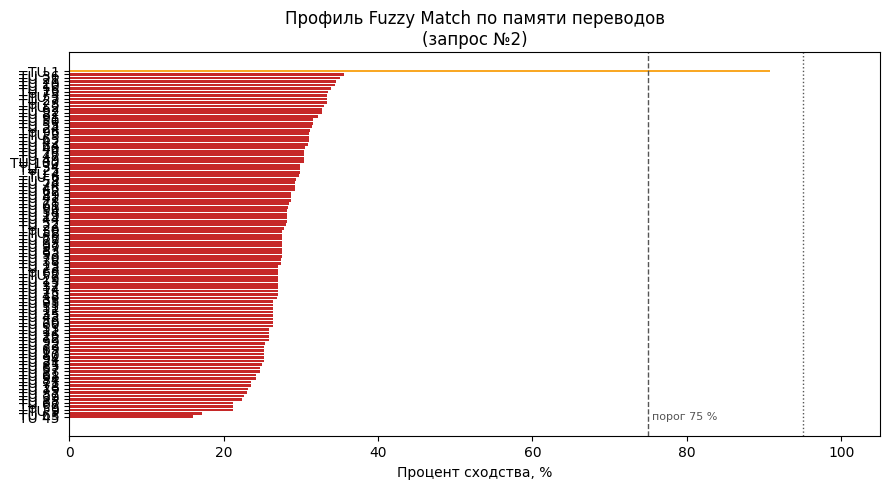

Максимум: 90.80 %   медиана: 27.59 %


In [11]:
probe = QUERIES[1]["query"]
scores = [similarity(probe, seg)["score"] for seg in tm_df["source_segment"]]
profile = (pd.DataFrame({"tuid": tm_df["tuid"], "score": scores})
           .sort_values("score", ascending=True))

colors = ["#2e7d32" if value >= 95 else "#f9a825" if value >= 75 else "#c62828"
          for value in profile["score"]]

figure, axes = plt.subplots(figsize=(9, 5))
axes.barh([f"TU {tuid}" for tuid in profile["tuid"]], profile["score"], color=colors)
axes.axvline(75, color="#555555", linestyle="--", linewidth=1)
axes.axvline(95, color="#555555", linestyle=":", linewidth=1)
axes.set_xlim(0, 105)
axes.set_xlabel("Процент сходства, %")
axes.set_title("Профиль Fuzzy Match по памяти переводов\n(запрос №2)")
axes.text(75.5, -0.6, "порог 75 %", fontsize=8, color="#555555")
figure.tight_layout()
plt.show()

print(f"Максимум: {max(scores):.2f} %   медиана: {pd.Series(scores).median():.2f} %")

## Блок 7. Интеграция глоссария: подстановка терминов (2 балла)

Терминологическая разметка выполняется по правилам, принятым в CAT-системах:

* кандидаты сортируются по убыванию длины — многословный термин
  «uncrewed aircraft system» должен сработать раньше, чем «aircraft»;
* поиск регистронезависимый, но по границам слов, чтобы «pitot» не совпал
  внутри другого слова;
* уже размеченные фрагменты повторно не обрабатываются (защита от вложенных
  подстановок).

### Пояснение к блоку 7

**Что делает блок.** Ищет в исходном предложении известные термины и добавляет рядом их переводные эквиваленты из TBX-глоссария.

**Почему термины сортируются по длине.** Если сначала заменить короткий термин, он может разрушить более длинное словосочетание. Поэтому многословные единицы обрабатываются раньше.

**Почему используются границы слов.** Регулярное выражение `(?<!\w)...(?!\w)` предотвращает случайное совпадение термина как части другого слова.

**Зачем нужны временные маркеры `\x00...\x00`.** Уже выполненная подстановка временно защищается от повторной обработки. После завершения поиска маркеры заменяются на готовые фрагменты.

**Что показывает `glossary_coverage()`.** Функция не изменяет текст, а возвращает список найденных терминов. Это позволяет измерять терминологическое покрытие сегмента.

**Педагогический акцент.** Блок демонстрирует принцип контролируемой терминологии: автоматизация помогает не «переводить вместо человека», а снижать риск непоследовательного употребления специальных терминов.


In [12]:
def apply_term_glossary(text: str, glossary_df: pd.DataFrame,
                        template: str = "{source} [{target}]") -> str:
    """Разметить исходный текст переводными эквивалентами из глоссария.

    Args:
        text: исходный сегмент на языке оригинала.
        glossary_df: таблица глоссария (результат :func:`parse_tbx`) с колонками
            ``source_term`` и ``target_term``.
        template: шаблон подстановки; поля ``{source}`` и ``{target}``.

    Returns:
        Текст, в котором найденные термины заменены по шаблону. Порядок слов и
        регистр исходного текста сохраняются.
    """
    if glossary_df.empty or not text:
        return text

    pairs = sorted(
        zip(glossary_df["source_term"], glossary_df["target_term"]),
        key=lambda pair: len(pair[0]), reverse=True,
    )

    protected: List[str] = []

    def _store(replacement: str) -> str:
        protected.append(replacement)
        return f"\x00{len(protected) - 1}\x00"

    result = text
    for source_term, target_term in pairs:
        pattern = re.compile(rf"(?<!\w){re.escape(source_term)}(?!\w)", re.IGNORECASE)
        result = pattern.sub(
            lambda match: _store(template.format(source=match.group(0), target=target_term)),
            result,
        )

    return re.sub(r"\x00(\d+)\x00", lambda m: protected[int(m.group(1))], result)


def glossary_coverage(text: str, glossary_df: pd.DataFrame) -> List[str]:
    """Вернуть список терминов глоссария, найденных в тексте."""
    found: List[str] = []
    for term in glossary_df["source_term"]:
        if re.search(rf"(?<!\w){re.escape(term)}(?!\w)", text, re.IGNORECASE):
            found.append(term)
    return found


DEMO_SEGMENTS = [
    "Previously, Russia had primarily stored its spent fuel and partly processed this fuel at the RT-1 plant at the Mayak Production Association near Ekaterinburg, about 1600 kilometers east of Moscow, in western Siberia.",
    "Ghana has successfully completed the conversion of its only research reactor from the use of high enriched uranium (HEU) fuel to low enriched uranium (LEU) fuel, in an international project supported by the IAEA to help decrease the proliferation risks associated with HEU fuel.",
    "Initially, all countries had planned to reprocess their spent fuel, either in their own facilities or abroad.",
]

for segment in DEMO_SEGMENTS:
    print("-" * 100)
    print(f"Исходный сегмент : {segment}")
    print(f"С подстановкой   : {apply_term_glossary(segment, glossary_df)}")
    print(f"Найдено терминов : {len(glossary_coverage(segment, glossary_df))} "
          f"-> {glossary_coverage(segment, glossary_df)}")

----------------------------------------------------------------------------------------------------
Исходный сегмент : Previously, Russia had primarily stored its spent fuel and partly processed this fuel at the RT-1 plant at the Mayak Production Association near Ekaterinburg, about 1600 kilometers east of Moscow, in western Siberia.
С подстановкой   : Previously, Russia had primarily stored its spent fuel [отработавшее топливо] and partly processed this fuel at the RT-1 plant at the Mayak Production Association near Ekaterinburg, about 1600 kilometers east of Moscow, in western Siberia.
Найдено терминов : 1 -> ['spent fuel']
----------------------------------------------------------------------------------------------------
Исходный сегмент : Ghana has successfully completed the conversion of its only research reactor from the use of high enriched uranium (HEU) fuel to low enriched uranium (LEU) fuel, in an international project supported by the IAEA to help decrease the proliferatio

### 7.1. Симуляция работы переводчика: ТМ + глоссарий

Для каждого сегмента документа система сначала ищет совпадение в памяти
переводов; если процент ниже 75 %, сегмент передаётся переводчику с
предварительной терминологической разметкой.

### Пояснение к симуляции 7.1

Этот блок объединяет две ранее независимые технологии в единый рабочий процесс. Для каждого нового сегмента сначала выполняется поиск в TMX-памяти. Если найден подходящий кандидат, переводчику предлагается готовый или частично готовый перевод. Если совпадения нет, включается терминологическая подсказка из TBX.

Получается упрощённая модель поведения CAT-системы:

`новый сегмент → поиск в TM → оценка процента → предложение перевода или подсказка из глоссария`.

В таблице `pipeline_df` фиксируются тип совпадения, процент, предлагаемая подсказка и рекомендуемое действие. Это уже не отдельный алгоритм, а небольшой **конвейер поддержки принятия решения переводчиком**.

Для педагогической аудитории здесь полезно подчеркнуть идею человеко-машинного взаимодействия: система автоматизирует рутинный поиск и предлагает варианты, но окончательное решение остаётся за специалистом.


In [13]:
DOCUMENT = [
    "The movement of nuclear material requires additional safety and security measures.",# ожидается ICE
    "It is therefore placed in water pool or in dry storage facility to cool up.",# ожидается Fuzzy
    "The quarterly financial report was approved by the board of directors.",# ожидается No match
]

pipeline_rows: List[Dict[str, Any]] = []
previous_segment: Optional[str] = "Previously, Russia had primarily stored its spent fuel and partly processed this fuel at the RT-1 plant at the Mayak Production Association near Ekaterinburg, about 1600 kilometers east of Moscow, in western Siberia."

for segment in DOCUMENT:
    matches = calculate_fuzzy_match(segment, tm_df, threshold=75.0,
                                    context_before=previous_segment, top_n=1)
    if matches:
        best = matches[0]
        action = "подставить из ТМ" if best["score"] >= 95 else "отредактировать вариант из ТМ"
        pipeline_rows.append({
            "segment": segment,
            "match_type": best["match_type"],
            "score": best["score"],
            "suggestion": best["target_segment"],
            "action": action,
        })
    else:
        pipeline_rows.append({
            "segment": segment,
            "match_type": "No Match",
            "score": 0.0,
            "suggestion": apply_term_glossary(segment, glossary_df),
            "action": "перевод с нуля по глоссарию",
        })
    previous_segment = segment

pipeline_df = pd.DataFrame(pipeline_rows)
for row in pipeline_rows:
    print("=" * 100)
    print(f"Сегмент    : {row['segment']}")
    print(f"Совпадение : {row['match_type']} ({row['score']:.2f} %) -> {row['action']}")
    print(f"Подсказка  : {row['suggestion']}")

print("=" * 100)
pipeline_df[["match_type", "score", "action"]]

Сегмент    : The movement of nuclear material requires additional safety and security measures.
Совпадение : ICE (101%) (100.00 %) -> подставить из ТМ
Подсказка  : При перемещении ядерного материала требуется принимать дополнительные меры по обеспечению физической и ядерной безопасности.
Сегмент    : It is therefore placed in water pool or in dry storage facility to cool up.
Совпадение : Fuzzy (89.87 %) -> отредактировать вариант из ТМ
Подсказка  : Поэтому для охлаждения его помещают в бассейны с водой или в сухие хранилища.
Сегмент    : The quarterly financial report was approved by the board of directors.
Совпадение : No Match (0.00 %) -> перевод с нуля по глоссарию
Подсказка  : The quarterly financial report was approved by the board of directors.


,match_type,score,action
0,ICE (101%),100.00,подставить из ТМ
1,Fuzzy,89.87,отредактировать вариант из ТМ
2,No Match,0.00,перевод с нуля по глоссарию


## Блок 8. Экспорт результатов для Smartcat

Smartcat импортирует глоссарии из CSV с заголовком вида
`Source (en);Target (ru);Comment` (UTF-8, разделитель — запятая или точка с
запятой). Память переводов загружается напрямую в формате `.tmx`.

Выгружаются три файла:

| Файл | Назначение |
|------|------------|
| `glossary_smartcat_v25.csv` | импорт глоссария в Smartcat |
| `tm_segments_v25.csv` | таблица параллельных сегментов для проверки |
| `fuzzy_report_v25.csv` | отчёт по найденным нечётким совпадениям |

### Пояснение к блоку 8

**Что делает блок.** Преобразует внутренние таблицы `pandas` в файлы, которые можно передать во внешнюю систему или использовать в отчёте.

**Почему используется CSV.** После сложной XML-обработки результат часто нужен в простой табличной форме. CSV хорошо подходит для обмена между Python, электронными таблицами и CAT-системами.

**Три вида экспорта имеют разные задачи.**
- `glossary_smartcat_v25.csv` — практический импорт терминов;
- `tm_segments_v25.csv` — контрольная таблица содержимого памяти переводов;
- `fuzzy_report_v25.csv` — аналитический отчёт о найденных совпадениях.

**Обратите внимание на `encoding="utf-8-sig"`.** Такая кодировка помогает корректно открывать русский текст в программах, которые ожидают BOM при чтении UTF-8.

**Результат блока.** Ноутбук не только выполняет вычисления, но и создаёт переносимые артефакты — важный этап любой прикладной работы с данными.


In [14]:
GLOSSARY_CSV = "glossary_smartcat_v8.csv"
TM_CSV = "tm_segments_v8.csv"
FUZZY_CSV = "fuzzy_report_v8.csv"

smartcat_df = pd.DataFrame({
    "Source (en)": glossary_df["source_term"],
    "Target (ru)": glossary_df["target_term"],
    "Comment": glossary_df["definition"],
})
smartcat_df.to_csv(GLOSSARY_CSV, index=False, encoding="utf-8-sig",
                   quoting=csv.QUOTE_MINIMAL)

tm_df[["tuid", "source_segment", "target_segment", "domain"]].to_csv(
    TM_CSV, index=False, encoding="utf-8-sig")

matches_df[["query", "tuid", "source_segment", "target_segment",
            "score", "lev_ratio", "token_sort_ratio", "match_type"]].to_csv(
    FUZZY_CSV, index=False, encoding="utf-8-sig")

print("Экспортированные файлы:")
for name in [TBX_PATH, TMX_PATH, GLOSSARY_CSV, TM_CSV, FUZZY_CSV]:
    print(f"  {name:<28} {os.path.getsize(name):>7} байт")

print("\nПревью glossary_smartcat_v8.csv:")
smartcat_df.head(5)

Экспортированные файлы:
  variant_8.tbx                  80193 байт
  variant_8.tmx                  69789 байт
  glossary_smartcat_v8.csv       18517 байт
  tm_segments_v8.csv             49096 байт
  fuzzy_report_v8.csv             1219 байт

Превью glossary_smartcat_v8.csv:


,Source (en),Target (ru),Comment
0,nuclear,ядерный,Relating to a nucleus; relating to or usin...
1,spent fuel,отработавшее топливо,Nuclear fuel that has been irradiated in a...
2,nuclear material,ядерный материал,Plutonium except that with isotopic concen...
3,high enriched uranium,высокообогащенный уран,Uranium containing 20% or more of the isot...
4,nuclear fuel,ядерное топливо,Fissionable nuclear material in the form o...


### 8.1. Итоговая сводка по работе

### Пояснение к итоговой сводке 8.1

Сводная таблица объединяет ключевые показатели лабораторной работы: корректность TBX, число единиц TMX, количество найденных Fuzzy Match, число ICE-совпадений и количество терминологических подстановок.

Это пример **автоматической самопроверки результата**. Вместо того чтобы оценивать работу только визуально, программа формирует измеримые показатели и статусы. Такой подход полезен и в учебных заданиях: критерии оценивания можно связывать с проверяемыми результатами выполнения программы.


In [15]:
summary = pd.DataFrame([
    {"Этап": "1. Парсинг и валидация TBX", "Метрика": "термостатей",
     "Значение": report["entries"], "Статус": "OK" if report["valid"] else "ОШИБКА"},
    {"Этап": "2. Парсинг TMX", "Метрика": "единиц перевода",
     "Значение": len(tm_df), "Статус": "OK" if len(tm_df) >= 10 else "МАЛО ДАННЫХ"},
    {"Этап": "3. Fuzzy Match", "Метрика": "кандидатов выше порога",
     "Значение": len(matches_df), "Статус": "OK"},
    {"Этап": "3. ICE", "Метрика": "контекстных совпадений",
     "Значение": int((matches_df["match_type"] == "ICE (101%)").sum()), "Статус": "OK"},
    {"Этап": "4. Глоссарий", "Метрика": "терминов подставлено (демо)",
     "Значение": sum(len(glossary_coverage(s, glossary_df)) for s in DEMO_SEGMENTS),
     "Статус": "OK"},
])
print(summary.to_string(index=False))

                      Этап                     Метрика  Значение Статус
1. Парсинг и валидация TBX                 термостатей       100     OK
            2. Парсинг TMX             единиц перевода       100     OK
            3. Fuzzy Match      кандидатов выше порога         2     OK
                    3. ICE      контекстных совпадений         1     OK
              4. Глоссарий терминов подставлено (демо)         5     OK


## Выводы

1. Стандарт **TBX** (ISO 30042) описывает понятие как `termEntry` с одной
   `langSet` на язык; допускаются две формы записи термина — компактная `tig`
   и расширенная `ntig/termGrp`, поэтому надёжный парсер обязан обходить
   `langSet` целиком, а не рассчитывать на фиксированный путь.
2. Стандарт **TMX 1.4b** хранит выравненные сегменты как `tu → tuv → seg`;
   язык варианта задаётся атрибутом `xml:lang`, который в парсере раскрывается
   в полное имя с пространством имён XML.
3. Расстояние Левенштейна даёт базовую метрику Fuzzy Match, но чувствительно к
   перестановкам слов; комбинация с **Token Sort Ratio** повышает полноту
   выдачи без потери точности.
4. **ICE (In-Context Exact Match)** отличается от обычного 100 %-совпадения
   учётом соседних сегментов — только он позволяет подставлять перевод без
   проверки редактором.
5. Автоматическая терминологическая разметка требует сортировки терминов по
   убыванию длины и защиты уже размеченных фрагментов, иначе многословные
   термины разрушаются вложенными подстановками.

### Методический итог для преподавателя

Лабораторная работа связывает три уровня понимания:

1. **Форматы данных** — студент различает TBX, TMX и CSV и понимает их назначение.
2. **Алгоритмы обработки** — студент видит парсинг XML, нормализацию текста, расстояние Левенштейна, ранжирование и регулярные выражения.
3. **Прикладной сценарий** — отдельные алгоритмы объединяются в модель CAT-системы, где память переводов и терминологическая база совместно поддерживают работу переводчика.

Для педагогической аудитории особенно важно обсуждать не только программную реализацию, но и **дидактический смысл автоматизации**: какие действия пользователя снимает система, какие решения остаются за человеком, какие ошибки можно обнаружить автоматически и какие метрики позволяют оценить качество результата.
